
# 📡 Microsoft Indoor Localization – Real Data Flow

This notebook replicates the logic from the **simulated data** section, but now applies it to the **real Microsoft Wi-Fi data**, including:
- Building a **Signal Graph** from train and test data
- Creating an **Area Graph** using sampled walkable points

---


In [3]:

import pandas as pd
import numpy as np
import networkx as nx
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.image import imread
from sklearn.metrics.pairwise import euclidean_distances
from tqdm import tqdm
import json


In [4]:
site = "5a0546857ecc773753327266"
floor = 2
wifi_root = r"C:\Users\Noa\Documents\GitHub\indoor_localization_research\Data\Microsoft data\wifi_features"
metadata_root = r"C:\Users\Noa\Documents\GitHub\indoor_localization_research\Data\Microsoft data\Data\metadata"


In [5]:

def load_clean_wifi_data(site, floor, wifi_root, split):
    fstr = f"F{floor}" if not str(floor).upper().startswith("F") else str(floor).upper()
    path = Path(wifi_root) / split / f"{site}_1000_{split}.csv"
    df = pd.read_csv(path, index_col=0)
    df = df[df["f"].astype(str).str.upper().str.replace("^F", "", regex=True) == fstr.replace("F", "")].copy()
    df.drop(columns=[col for col in df.columns if col.lower() in {"f", "path"}], inplace=True, errors="ignore")
    df.drop(columns=[df.columns[0]], inplace=True)  # Drop unnamed first col
    df.replace(-999, np.nan, inplace=True)
    df.dropna(axis=1, how="all", inplace=True)
    df.fillna(-100, inplace=True)
    return df


In [6]:
file_path = r"C:\Users\Noa\Documents\GitHub\indoor_localization_research\df_preprocess_cleaned_5a0546857ecc773753327266_F1.csv"
data = pd.read_csv(file_path)
NUM_RECIVERS = len([c for c in data.columns if c not in ["x", "y"]])
print(NUM_RECIVERS)
points_with_signals_df = data

903


In [7]:

def build_signal_graph(df, k=10):
    positions = df[["x", "y"]].values
    signals = df.drop(columns=["x", "y"]).values
    dist_mat = euclidean_distances(signals, signals)
    np.fill_diagonal(dist_mat, np.inf)
    
    G = nx.Graph()
    for i, pos in enumerate(positions):
        G.add_node(i, pos=pos)

    for i in tqdm(range(len(df))):
        nearest_idx = np.argsort(dist_mat[i])[:k]
        for j in nearest_idx:
            G.add_edge(i, j, weight=dist_mat[i, j])

    return G

G_signal = build_signal_graph(points_with_signals_df, k=10)
print(f"Graph: {len(G_signal.nodes)} nodes, {len(G_signal.edges)} edges")


100%|██████████| 2268/2268 [00:00<00:00, 23627.94it/s]

Graph: 2268 nodes, 13434 edges


In [8]:

def plot_floor_points_from_wifi_csv(site, floor, wifi_root, metadata_root, split="train", sample=3000):
    fstr = f"F{floor}" if not str(floor).upper().startswith("F") else str(floor).upper()
    csv_path = Path(wifi_root) / split / f"{site}_1000_{split}.csv"
    df = pd.read_csv(csv_path, index_col=0)
    df_floor = df[df["f"].astype(str).str.upper().str.replace("^F", "", regex=True) == fstr.replace("F", "")]
    if len(df_floor) > sample:
        df_floor = df_floor.sample(sample, random_state=42)
    points = df_floor[["x", "y"]].to_numpy()

    floor_dir = Path(metadata_root) / site / fstr
    image_path = next(floor_dir.glob("floor_image.*"))
    img = imread(str(image_path))

    json_path = floor_dir / "floor_info.json"
    with open(json_path, "r") as f:
        metadata = json.load(f)
    width_meter = metadata["map_info"]["width"]
    height_meter = metadata["map_info"]["height"]
    extent = (0, width_meter, 0, height_meter)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(img, extent=extent, origin='upper', alpha=0.85)
    # ax.scatter(points[:, 0], points[:, 1], c="red", s=10, label="Sampled Points")
    ax.set_xlim([0, width_meter])
    ax.set_ylim([0, height_meter])
    ax.set_title(f"Site {site} | Floor {floor} | {split} data")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, linestyle="--", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


C:\Users\Noa\AppData\Local\Temp\ipykernel_25996\731275019.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


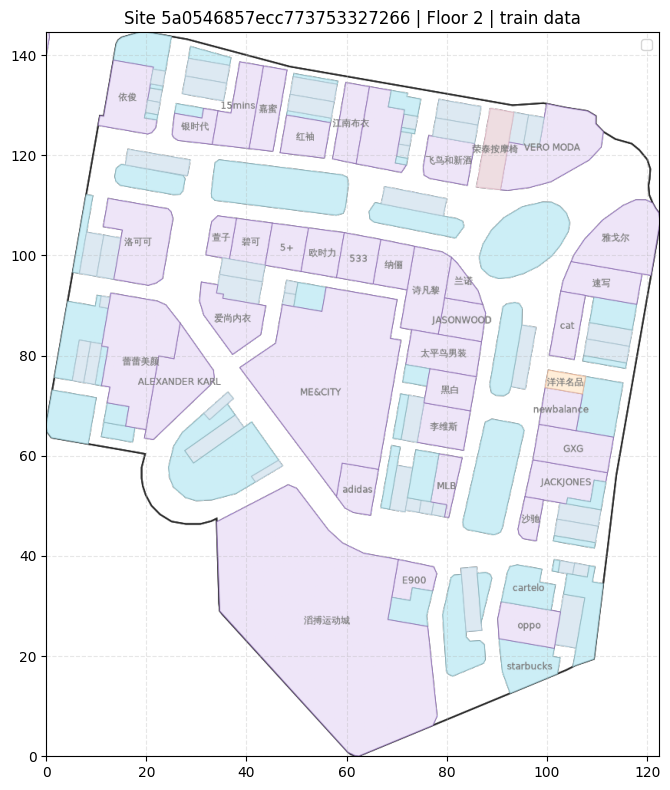

In [9]:

plot_floor_points_from_wifi_csv(
    site=site,
    floor=floor,
    wifi_root=wifi_root,
    metadata_root=metadata_root,
    split="train",
    sample=1000
)


find the white area inside the blace line

In [10]:
fstr = f"F{floor}" if not str(floor).upper().startswith("F") else str(floor).upper()
img_path = next((Path(metadata_root)/site/fstr).glob("floor_image.*"))

In [18]:
import cv2
import numpy as np
from pathlib import Path

def draw_lightareas_border_red_from_metadata_v3(
    site, floor, metadata_root,
    *,
    red_thickness=4,

    # Outline detection / robustness
    black_V_max=110,    # raise if walls are gray
    close_iters=3,
    dilate_black_px=1,

    # Classic “white / light” gate (broad)
    white_S_max=80,
    white_V_min=185,

    # Pastel gate (ANY hue, just light & low saturation)
    pastel_S_max=90,    # catch very light lavender/cyan
    pastel_V_min=165,

    # Explicit hues (widened bands)
    cyan_H=(80, 100),   cyan_S_min=25,  cyan_V_min=110,
    blue_H=(90, 140),   blue_S_min=25,  blue_V_min=110,
    purple_H=(120, 175), purple_S_min=20, purple_V_min=105,

    min_area_px=80,
    shrink_px=1,
    return_masks=False
):
    """Draw red border around union of light/white + cyan/blue/purple areas inside the black outline."""
    fstr = f"F{floor}" if not str(floor).upper().startswith("F") else str(floor).upper()
    img_path = next((Path(metadata_root)/site/fstr).glob("floor_image.*"))
    img_rgb = imread(str(img_path))
    if img_rgb.dtype != np.uint8:
        img_rgb = (np.clip(img_rgb, 0, 1) * 255).astype(np.uint8)

    H, W = img_rgb.shape[:2]
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

    # --- black outline ---
    black = cv2.inRange(hsv, np.array([0,0,0], np.uint8),
                             np.array([180,255,black_V_max], np.uint8))
    black = cv2.morphologyEx(black, cv2.MORPH_CLOSE, np.ones((3,3), np.uint8), iterations=close_iters)
    if dilate_black_px > 0:
        k = 2*dilate_black_px+1
        black = cv2.dilate(black, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k,k)), 1)

    # --- compute inside via flood-fill from edges ---
    ff_src = (black == 0).astype(np.uint8) * 255
    ff = np.pad(ff_src, ((1,1),(1,1)), mode="constant")
    mask_ff = np.zeros((ff.shape[0]+2, ff.shape[1]+2), np.uint8)
    for seed in [(1,1), (ff.shape[1]-2,1), (1,ff.shape[0]-2), (ff.shape[1]-2,ff.shape[0]-2)]:
        cv2.floodFill(ff, mask_ff, seed, 128)
    outside = (ff[1:-1,1:-1] == 128).astype(np.uint8) * 255
    inside  = cv2.bitwise_and(cv2.bitwise_not(outside), cv2.bitwise_not(black))

    # --- gates ---
    # 1) broad white/light
    white = cv2.inRange(hsv, np.array([0,0,white_V_min], np.uint8),
                             np.array([180,white_S_max,255], np.uint8))
    # 2) pastel (any hue): low S, high V
    s = hsv[...,1]; v = hsv[...,2]
    pastel = np.zeros((H,W), np.uint8)
    pastel[(s <= pastel_S_max) & (v >= pastel_V_min)] = 255

    # 3) explicit cyan / blue / purple (wider)
    def hue_mask(h_lo, h_hi, s_min, v_min):
        return cv2.inRange(hsv,
                           np.array([h_lo, s_min, v_min], np.uint8),
                           np.array([h_hi, 255, 255], np.uint8))
    cyan   = hue_mask(*cyan_H,   cyan_S_min,   cyan_V_min)
    blue   = hue_mask(*blue_H,   blue_S_min,   blue_V_min)
    purple = hue_mask(*purple_H, purple_S_min, purple_V_min)

    # union, constrained to inside, excluding walls
    target = white | pastel | cyan | blue | purple
    target = cv2.bitwise_and(target, inside)
    target = cv2.bitwise_and(target, cv2.bitwise_not(black))

    # clean & shrink slightly so line stays off the wall
    target = cv2.morphologyEx(target, cv2.MORPH_OPEN, np.ones((3,3), np.uint8), 1)
    if shrink_px > 0:
        k = 2*shrink_px+1
        target = cv2.erode(target, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k,k)), 1)

    cnts, _ = cv2.findContours(target, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = [c for c in cnts if cv2.contourArea(c) >= min_area_px]

    overlay = img_rgb.copy()
    cv2.drawContours(overlay, cnts, -1, (255,0,0), thickness=red_thickness)

    if return_masks:
        return overlay, {
            "black": black, "inside": inside,
            "white": white, "pastel": pastel,
            "cyan": cyan, "blue": blue, "purple": purple,
            "target": target
        }
    return overlay


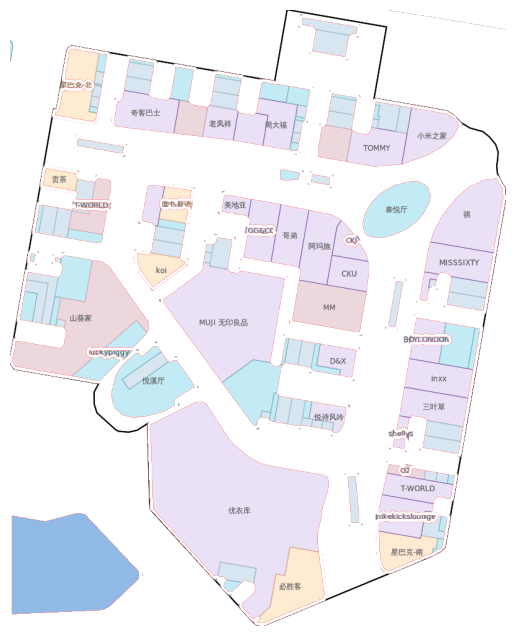

In [19]:
overlay = draw_lightareas_border_red_from_metadata_v3(
    site=site, floor=floor, metadata_root=metadata_root,
    red_thickness=4,
    black_V_max=110, close_iters=3, dilate_black_px=1,
    white_S_max=80, white_V_min=185,
    pastel_S_max=90, pastel_V_min=165,
    cyan_H=(80,100), blue_H=(90,140), purple_H=(120,175),
    min_area_px=80, shrink_px=1
)

import matplotlib.pyplot as plt
plt.figure(figsize=(8,8))
plt.imshow(overlay)
plt.axis('off')
plt.show()


In [14]:
overlay, masks = draw_lightareas_border_red_from_metadata_v3(
    site=site, floor=floor, metadata_root=metadata_root, return_masks=True
)

# Binary mask that marks all detected areas inside the border
target = masks["target"]          # shape (H, W), uint8 {0,255}

cnts, _ = cv2.findContours(target, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print(len(cnts), cnts[0].shape)   # e.g., (num_polygons, (N_i, 1, 2))


29 (94, 1, 2)


In [15]:
import cv2
import numpy as np
from pathlib import Path

def corridor_mask_strict_inside(
    site, floor, metadata_root,
    *,
    # Background / interior detection
    bg_V_max=18,                 # V<=bg_V_max → background (black/dark)
    keep_cc="largest",           # use largest non-background CC as building interior

    # Walls (very dark strokes)
    wall_V_max=45,               # V<=wall_V_max → wall stroke
    wall_close_iters=2,
    wall_dilate_px=1,

    # Shops (colored regions)
    shop_S_min=32,               # S>=shop_S_min → colored
    shop_V_min=95,               # V>=shop_V_min → bright enough to be a shop
    # optional hue bands common in these maps
    cyan_H=(80,100),   cyan_S_min=25,   cyan_V_min=90,
    blue_H=(90,140),   blue_S_min=25,   blue_V_min=90,
    purple_H=(120,175),purple_S_min=18, purple_V_min=85,

    # Corridor cleanup
    min_corridor_area=1000,
    corridor_dilate_px=2
):
    """
    Returns: mask (H,W) uint8 {0,255}
      255 = corridor (non-colored) strictly INSIDE building
      0   = shops, walls, outside background
    """
    fstr = f"F{floor}" if not str(floor).upper().startswith("F") else str(floor).upper()
    img_path = next((Path(metadata_root)/site/fstr).glob("floor_image.*"))
    img = imread(str(img_path))
    if img.dtype != np.uint8:
        img = (np.clip(img, 0, 1) * 255).astype(np.uint8)
    if img.ndim == 3 and img.shape[2] == 4:
        img = cv2.cvtColor(img, cv2.COLOR_RGBA2RGB)

    H, W = img.shape[:2]
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    S, V = hsv[...,1], hsv[...,2]

    # --- INSIDE (building interior) = largest non-background CC ---
    not_bg = (V > bg_V_max).astype(np.uint8) * 255
    num, labels = cv2.connectedComponents(not_bg)
    if num <= 1:
        return np.zeros((H, W), np.uint8)
    if keep_cc == "largest":
        sizes = np.bincount(labels.ravel())
        sizes[0] = 0
        cc_id = int(np.argmax(sizes))
        inside = (labels == cc_id).astype(np.uint8) * 255
    else:
        inside = not_bg

    # --- WALLS ---
    walls = cv2.inRange(hsv, (0,0,0), (180,255,wall_V_max))
    walls = cv2.morphologyEx(walls, cv2.MORPH_CLOSE, np.ones((3,3), np.uint8), wall_close_iters)
    if wall_dilate_px > 0:
        k = 2*wall_dilate_px + 1
        walls = cv2.dilate(walls, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k,k)), 1)
    # ensure walls are considered only inside
    walls = cv2.bitwise_and(walls, inside)

    # --- SHOPS (colored) ---
    colored_generic = ((S >= shop_S_min) & (V >= shop_V_min)).astype(np.uint8) * 255
    def hue_mask(hlo, hhi, smin, vmin):
        return cv2.inRange(hsv, (hlo, smin, vmin), (hhi, 255, 255))
    cyan   = hue_mask(*cyan_H,   cyan_S_min,   cyan_V_min)
    blue   = hue_mask(*blue_H,   blue_S_min,   blue_V_min)
    purple = hue_mask(*purple_H, purple_S_min, purple_V_min)

    shops = colored_generic | cyan | blue | purple
    # shops only inside
    shops = cv2.bitwise_and(shops, inside)
    # shops not walls
    shops = cv2.bitwise_and(shops, cv2.bitwise_not(walls))

    # --- CORRIDORS = INSIDE − SHOPS − WALLS (strictly inside) ---
    corridors = cv2.bitwise_and(inside, cv2.bitwise_not(shops))
    corridors = cv2.bitwise_and(corridors, cv2.bitwise_not(walls))

    # --- cleanup: drop tiny blobs and smooth ---
    cnts, _ = cv2.findContours(corridors, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mask = np.zeros_like(corridors)
    for c in cnts:
        if cv2.contourArea(c) >= min_corridor_area:
            cv2.drawContours(mask, [c], -1, 255, thickness=cv2.FILLED)

    if corridor_dilate_px > 0:
        k = 2*corridor_dilate_px + 1
        mask = cv2.dilate(mask, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k,k)), 1)

    # final safety: **force** inside constraint
    mask = cv2.bitwise_and(mask, inside)

    return mask


In [16]:
img = imread(str(img_path))
overlay = cv2.cvtColor(img, cv2.COLOR_RGB2BGR).copy()
overlay[mask > 0] = (0, 255, 255)  # highlight corridors in yellow

plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title("Mask Overlay on Map")
plt.axis('off')
plt.show()



NameError: name 'mask' is not defined

In [ ]:
import cv2
import numpy as np
from typing import Tuple, Dict, Union

ArrayLike = np.ndarray

def load_bgr(img_or_path: Union[str, ArrayLike]) -> ArrayLike:
    """Load an image as 3-channel BGR. Converts RGBA → BGR safely."""
    if isinstance(img_or_path, str):
        img = cv2.imread(img_or_path, cv2.IMREAD_UNCHANGED)
        if img is None:
            raise FileNotFoundError(f"Could not read image at: {img_or_path}")
    else:
        img = img_or_path

    if img.ndim == 2:  # grayscale → BGR
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    elif img.shape[2] == 4:  # BGRA → BGR
        img = cv2.cvtColor(img, cv2.COLOR_BGRA2BGR)
    elif img.shape[2] != 3:
        raise ValueError(f"Unexpected channel count: {img.shape}")
    return img

def get_interior_noncolor_mask(
    img_or_path: Union[str, ArrayLike],
    *,
    # wall (black outline) detection
    black_V_max: int = 110,
    close_iters: int = 3,
    dilate_black_px: int = 1,

    # “colorful” definitions
    sat_color_S_min: int = 40,   # saturated colors
    sat_color_V_min: int = 90,
    pastel_S_max: int   = 88,    # pale stores (low S, high V)
    pastel_V_min: int   = 165,

    # extra hue bands that often appear as store fills
    hue_bands: Tuple[Tuple[int,int,int,int], ...] = (
        (80, 100, 25, 110),   # cyan
        (90, 140, 25, 110),   # blue
        (120, 175, 20, 105),  # purple
        (160, 179, 25, 110),  # pink/magenta
    ),

    # cleanup knobs
    open_ksize: int = 3,
    min_hole_area_px: int = 200,
    min_component_area_px: int = 20,

    return_debug: bool = False,
) -> Tuple[ArrayLike, Dict[str, ArrayLike]]:
    """
    Returns:
        mask (H,W) uint8 in {0,255}: interior, NOT colorful, NOT wall.
        debug dict if `return_debug` True.
    """
    img = load_bgr(str(img_or_path))
    h, w = img.shape[:2]
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # --- 1) Black outline (walls) ---
    walls = cv2.inRange(hsv,
                        np.array([0, 0, 0], np.uint8),
                        np.array([180, 255, black_V_max], np.uint8))
    walls = cv2.morphologyEx(walls, cv2.MORPH_CLOSE, np.ones((3,3), np.uint8), iterations=close_iters)
    if dilate_black_px > 0:
        k = 2*dilate_black_px + 1
        walls = cv2.dilate(walls, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k)), 1)

    # --- 2) Interior via border flood-fill ---
    # Fill starting from the outside (image frame) on the inverse of walls
    ff_src = (walls == 0).astype(np.uint8) * 255
    ff = np.pad(ff_src, ((1,1),(1,1)), mode="constant")  # padding so floodFill can hit borders
    ff_mask = np.zeros((ff.shape[0]+2, ff.shape[1]+2), np.uint8)
    corners = [(1,1), (ff.shape[1]-2,1), (1,ff.shape[0]-2), (ff.shape[1]-2,ff.shape[0]-2)]
    for seed in corners:
        cv2.floodFill(ff, ff_mask, seed, 128)
    outside = (ff[1:-1, 1:-1] == 128).astype(np.uint8) * 255
    inside  = cv2.bitwise_and(cv2.bitwise_not(outside), cv2.bitwise_not(walls))

    # --- 3) Colorful areas (to exclude) ---
    s = hsv[..., 1]
    v = hsv[..., 2]

    # saturated / “normal colorful”
    colorful_sat = cv2.inRange(hsv,
                               np.array([0, sat_color_S_min, sat_color_V_min], np.uint8),
                               np.array([179, 255, 255], np.uint8))

    # pastel (low S, high V) — common for store fills
    pastel = np.zeros((h, w), np.uint8)
    pastel[(s <= pastel_S_max) & (v >= pastel_V_min)] = 255

    # explicit hues (safety net)
    colorful_hues = np.zeros((h, w), np.uint8)
    for h_lo, h_hi, s_min, v_min in hue_bands:
        colorful_hues |= cv2.inRange(hsv,
                                     np.array([h_lo, s_min, v_min], np.uint8),
                                     np.array([h_hi, 255, 255], np.uint8))

    colorful = colorful_sat | pastel | colorful_hues

    # --- 4) Interior non-color mask ---
    mask = cv2.bitwise_and(inside, cv2.bitwise_not(colorful))
    mask = cv2.bitwise_and(mask, cv2.bitwise_not(walls))

    # cleanup small speckles
    if open_ksize > 1:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (open_ksize, open_ksize))
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, 1)

    # remove tiny components and fill tiny holes for stability
    # (a) remove very small components
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    clean = np.zeros_like(mask)
    for c in cnts:
        if cv2.contourArea(c) >= min_component_area_px:
            cv2.drawContours(clean, [c], -1, 255, -1)
    mask = clean

    # (b) fill small holes
    inv = cv2.bitwise_not(mask)
    holes, _ = cv2.findContours(inv, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for c in holes:
        if cv2.contourArea(c) <= min_hole_area_px:
            cv2.drawContours(inv, [c], -1, 0, -1)
    mask = cv2.bitwise_not(inv)

    if return_debug:
        return mask, {
            "walls": walls,
            "inside": inside,
            "colorful_sat": colorful_sat,
            "pastel": pastel,
            "colorful_hues": colorful_hues,
            "colorful_all": colorful
        }
    else:
        return mask, {}


In [ ]:
# 1) Get the mask
mask, dbg = get_interior_noncolor_mask(img_path, return_debug=True)

# 2) Save it (0/255 binary)
cv2.imwrite("noncolor_interior_mask.png", mask)

# 3) (Optional) Quick overlay that works for 3- or 4-channel inputs:
img = load_bgr(str(img_path))  # always BGR 3-channel here
overlay = img.copy()
overlay[mask > 0] = (0, 0, 255)  # paint in red
cv2.imwrite("noncolor_overlay.png", overlay)


True

In [ ]:
import cv2
import numpy as np
from pathlib import Path

def overlay_mask(
    img_path_or_bgr,
    mask,
    out_path="mask_overlay.png",
    mask_color=(0, 255, 255),  # Cyan highlight
    alpha=0.6
):
    # --- Accept Path / string / array safely ---
    if isinstance(img_path_or_bgr, (str, Path)):
        img = cv2.imread(str(img_path_or_bgr), cv2.IMREAD_UNCHANGED)
        if img is None:
            raise FileNotFoundError(f"Could not load: {img_path_or_bgr}")
    elif isinstance(img_path_or_bgr, np.ndarray):
        img = img_path_or_bgr.copy()
    else:
        raise TypeError("img_path_or_bgr must be a path or numpy image array")

    # Ensure RGB 3-channel
    if img.ndim == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    elif img.shape[2] == 4:  # BGRA → BGR
        img = cv2.cvtColor(img, cv2.COLOR_BGRA2BGR)

    # Ensure mask is single-channel
    if mask.ndim == 3:
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)

    # Create colored overlay only where mask=255
    overlay = img.copy()
    overlay[mask > 0] = mask_color

    # Blend
    blended = cv2.addWeighted(img, 1 - alpha, overlay, alpha, 0)

    cv2.imwrite(out_path, blended)
    print("Overlay saved:", out_path)
    return blended


In [ ]:
mask, dbg = get_interior_noncolor_mask(img_path)

overlay = overlay_mask(
    img_path,
    mask,
    out_path="mask_overlay.png",
    mask_color=(0, 255, 255),  # bright cyan
    alpha=0.6
)



Overlay saved: mask_overlay.png


In [ ]:
import cv2
import numpy as np

def save_debug_layers(dbg_dict, prefix="dbg_"):
    for k, v in dbg_dict.items():
        # binary masks -> ensure proper saving
        if v.ndim == 2:
            cv2.imwrite(f"{prefix}{k}.png", v)
        else:
            cv2.imwrite(f"{prefix}{k}.png", cv2.cvtColor(v, cv2.COLOR_BGR2GRAY))
        print("Saved:", f"{prefix}{k}.png")

# STEP 1 — generate mask with debug
mask, dbg = get_interior_noncolor_mask(img_path, return_debug=True)

# STEP 2 — save debug layers (walls, inside, colorful)
save_debug_layers(dbg)

# STEP 3 — overlay final mask to inspect visually
overlay_mask(img_path, mask, out_path="mask_overlay.png")


Saved: dbg_walls.png
Saved: dbg_inside.png
Saved: dbg_colorful_sat.png
Saved: dbg_pastel.png
Saved: dbg_colorful_hues.png
Saved: dbg_colorful_all.png
Overlay saved: mask_overlay.png


array([[[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]]

In [17]:
# 1) get hallway mask
hall_mask, dbg = get_hallway_inside_mask(img_path, return_debug=True)

# 2) quick overlay so you can judge it
def overlay_mask(img_or_path, mask, out_path="hall_overlay.png", color=(0,255,255), alpha=0.6):
    img = _load_bgr(img_or_path)
    overlay = img.copy()
    overlay[mask > 0] = color
    blended = cv2.addWeighted(img, 1 - alpha, overlay, alpha, 0)
    cv2.imwrite(out_path, blended)

overlay_mask(img_path, hall_mask, out_path="hall_overlay.png", color=(0,255,255), alpha=0.6)


NameError: name 'get_hallway_inside_mask' is not defined

In [18]:
import cv2
import numpy as np
from pathlib import Path
from typing import Union, Tuple, Dict

def _load_bgr(x: Union[str, Path, np.ndarray]) -> np.ndarray:
    if isinstance(x, (str, Path)):
        img = cv2.imread(str(x), cv2.IMREAD_UNCHANGED)
        if img is None:
            raise FileNotFoundError(x)
    else:
        img = x
    if img.ndim == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    elif img.shape[2] == 4:
        img = cv2.cvtColor(img, cv2.COLOR_BGRA2BGR)
    return img

def get_hallways_inside_building(
    img_or_path: Union[str, Path, np.ndarray],
    *,
    # define "black"
    black_V_max: int = 60,     # V <= this is black (hallways & walls); raise if hall looks dark-gray
    # footprint sealing / smoothing
    dilate_px: int = 9,        # merge stores to one blob to get building footprint
    close_iters: int = 2,
    erode_back_px: int = 7,    # shrink footprint after dilation so it hugs building
    # remove thin wall strokes
    min_thickness_px: int = 3, # keep only black regions thicker than this (removes 1–2 px walls)
    # cleanup
    min_area_px: int = 150,
    return_debug: bool = False,
) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
    """
    Returns:
      hall_mask: uint8 {0,255}, hallways ONLY (black interior regions), no exterior, no thin walls.
    """
    img = _load_bgr(img_or_path)
    H, W = img.shape[:2]
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # 1) mall footprint from NON-black pixels
    nonblack = (hsv[...,2] > black_V_max).astype(np.uint8) * 255

    # connect everything so entrances/holes seal
    k1 = 2*dilate_px + 1
    footprint_big = cv2.dilate(nonblack, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k1, k1)), 1)
    if close_iters > 0:
        footprint_big = cv2.morphologyEx(footprint_big, cv2.MORPH_CLOSE, np.ones((5,5), np.uint8), iterations=close_iters)

    # take the outer contour -> building footprint
    cnts, _ = cv2.findContours(footprint_big, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    footprint = np.zeros((H, W), np.uint8)
    if cnts:
        # choose the largest connected region as the mall footprint
        c = max(cnts, key=cv2.contourArea)
        cv2.drawContours(footprint, [c], -1, 255, thickness=-1)

    # shrink back so the footprint hugs the building reasonably
    if erode_back_px > 0:
        k2 = 2*erode_back_px + 1
        footprint = cv2.erode(footprint, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k2, k2)), 1)

    # 2) candidate hall pixels = black & inside footprint
    black = (hsv[...,2] <= black_V_max).astype(np.uint8) * 255
    halls_raw = cv2.bitwise_and(black, footprint)

    # 3) remove thin wall strokes using thickness (distance transform)
    #    keep only points whose distance to non-hall boundary >= min_thickness_px
    inv = cv2.bitwise_not(halls_raw)
    dist = cv2.distanceTransform(inv, cv2.DIST_L2, 5)
    thick = np.zeros_like(halls_raw)
    thick[dist > float(min_thickness_px)] = 255

    # 4) cleanup small blobs
    cnts, _ = cv2.findContours(thick, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    hall_mask = np.zeros_like(thick)
    for c in cnts:
        if cv2.contourArea(c) >= min_area_px:
            cv2.drawContours(hall_mask, [c], -1, 255, -1)

    if return_debug:
        return hall_mask, {
            "nonblack": nonblack,
            "footprint_big": footprint_big,
            "footprint": footprint,
            "black": black,
            "halls_raw": halls_raw,
            "thickness_dt": cv2.normalize(dist, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        }
    return hall_mask, {}


In [19]:
# get mask
hall_mask, dbg = get_hallways_inside_building(img_path, return_debug=True)

# visualize on top of the map
def overlay_mask(img_or_path, mask, out_path="hall_overlay.png", color=(0,255,255), alpha=0.6):
    img = _load_bgr(img_or_path)
    overlay = img.copy()
    overlay[mask > 0] = color
    blended = cv2.addWeighted(img, 1 - alpha, overlay, alpha, 0)
    cv2.imwrite(out_path, blended)
    return blended

overlay_mask(img_path, hall_mask, out_path="hall_overlay.png", color=(0,255,255), alpha=0.6)


array([[[  0, 153, 153],
        [  0, 153, 153],
        [  0, 153, 153],
        ...,
        [102, 255, 255],
        [102, 255, 255],
        [102, 255, 255]],

       [[  0, 153, 153],
        [  0, 153, 153],
        [  0, 153, 153],
        ...,
        [102, 255, 255],
        [102, 255, 255],
        [102, 255, 255]],

       [[  0, 153, 153],
        [  0, 153, 153],
        [  0, 153, 153],
        ...,
        [102, 255, 255],
        [102, 255, 255],
        [102, 255, 255]],

       ...,

       [[  0, 153, 153],
        [  0, 153, 153],
        [  0, 153, 153],
        ...,
        [  0, 153, 153],
        [  0, 153, 153],
        [  0, 153, 153]],

       [[  0, 153, 153],
        [  0, 153, 153],
        [  0, 153, 153],
        ...,
        [  0, 153, 153],
        [  0, 153, 153],
        [  0, 153, 153]],

       [[  0, 153, 153],
        [  0, 153, 153],
        [  0, 153, 153],
        ...,
        [  0, 153, 153],
        [  0, 153, 153],
        [  0, 153, 153]]

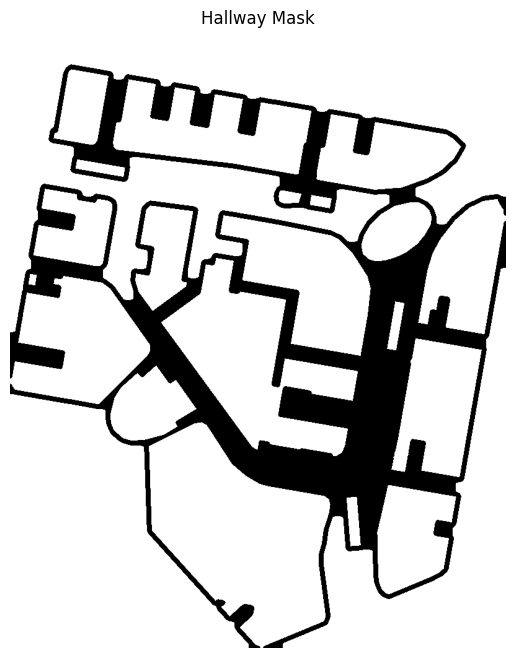

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.imshow(hall_mask, cmap='gray')
plt.title("Hallway Mask")
plt.axis('off')
plt.show()


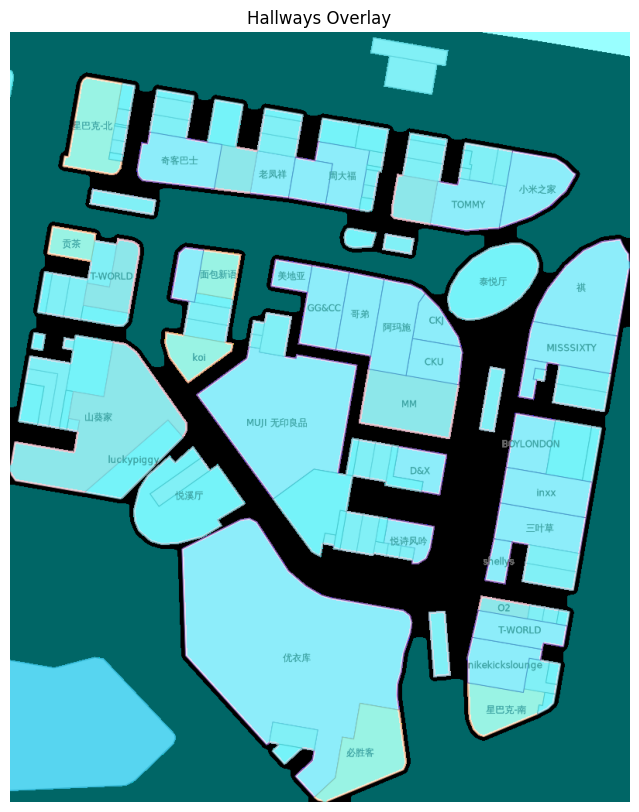

In [21]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(str(img_path))          # your original map
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# colorize the mask for visibility (cyan)
overlay = img.copy()
overlay[hall_mask > 0] = (0,255,255)

# blend them
blended = cv2.addWeighted(img, 0.6, overlay, 0.4, 0)

plt.figure(figsize=(10,10))
plt.imshow(blended)
plt.title("Hallways Overlay")
plt.axis('off')
plt.show()


In [22]:
import cv2
import numpy as np
from pathlib import Path
from typing import Union, Tuple, Dict

def _load_bgr(x: Union[str, Path, np.ndarray]) -> np.ndarray:
    if isinstance(x, (str, Path)):
        img = cv2.imread(str(x), cv2.IMREAD_UNCHANGED)
        if img is None:
            raise FileNotFoundError(x)
    else:
        img = x
    if img.ndim == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    elif img.shape[2] == 4:
        img = cv2.cvtColor(img, cv2.COLOR_BGRA2BGR)
    return img

def get_hallways_black_plus_teal(
    img_or_path: Union[str, Path, np.ndarray],
    *,
    # 1) Build mall footprint robustly (so “outside teal” is excluded)
    footprint_dilate_px: int = 12,    # increases sealing of door gaps; raise if footprint has holes
    footprint_close_iters: int = 2,
    footprint_erode_back_px: int = 7,

    # 2) Hallway candidates = BLACK or DARK-TEAL
    black_V_max: int = 60,           # <= this V is considered black
    # Teal band (tweak these to include your yellow-marked teal corridors)
    teal_H: Tuple[int,int] = (75, 120),
    teal_S: Tuple[int,int] = (15, 200),
    teal_V: Tuple[int,int] = (40, 200),

    # 3) Remove thin black wall strokes: keep only thick regions
    min_thickness_px: int = 2,       # 3–5 removes 1–2 px outlines, keeps corridors

    # 4) Cleanup
    close_hall_px: int = 3,          # small closing to bridge tiny gaps inside halls
    min_area_px: int = 150,          # discard tiny specks

    return_debug: bool = False,
) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
    """
    Returns:
      hall_mask: uint8 {0,255} where 255 = hallways (black + dark-teal) strictly inside the building.
    """
    img = _load_bgr(img_or_path)
    H, W = img.shape[:2]
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # ---------- 1) Mall footprint from NON-black pixels ----------
    nonblack = (hsv[...,2] > black_V_max).astype(np.uint8) * 255

    k1 = 2*footprint_dilate_px + 1
    footprint_big = cv2.dilate(nonblack, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k1, k1)), 1)
    if footprint_close_iters > 0:
        footprint_big = cv2.morphologyEx(footprint_big, cv2.MORPH_CLOSE, np.ones((5,5), np.uint8),
                                         iterations=footprint_close_iters)

    cnts, _ = cv2.findContours(footprint_big, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    footprint = np.zeros((H, W), np.uint8)
    if cnts:
        c = max(cnts, key=cv2.contourArea)
        cv2.drawContours(footprint, [c], -1, 255, thickness=-1)

    if footprint_erode_back_px > 0:
        k2 = 2*footprint_erode_back_px + 1
        footprint = cv2.erode(footprint, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k2, k2)), 1)

    # ---------- 2) Hallway candidates = BLACK or DARK-TEAL ----------
    black = (hsv[...,2] <= black_V_max).astype(np.uint8) * 255

    h, s, v = hsv[...,0], hsv[...,1], hsv[...,2]
    teal = np.zeros((H, W), np.uint8)
    teal[(h >= teal_H[0]) & (h <= teal_H[1]) &
         (s >= teal_S[0]) & (s <= teal_S[1]) &
         (v >= teal_V[0]) & (v <= teal_V[1])] = 255

    # Keep only inside the building footprint
    halls_raw = cv2.bitwise_and(footprint, cv2.bitwise_or(black, teal))

    # Optional small closing to connect tiny breaks inside corridors
    if close_hall_px > 0:
        k3 = 2*close_hall_px + 1
        halls_raw = cv2.morphologyEx(halls_raw, cv2.MORPH_CLOSE,
                                     cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k3, k3)), 1)

    # ---------- 3) Remove thin wall strokes by thickness ----------
    inv = cv2.bitwise_not(halls_raw)
    dist = cv2.distanceTransform(inv, cv2.DIST_L2, 5)
    thick = np.zeros_like(halls_raw)
    thick[dist > float(min_thickness_px)] = 255

    # ---------- 4) Cleanup small blobs ----------
    cnts, _ = cv2.findContours(thick, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    hall_mask = np.zeros_like(thick)
    for c in cnts:
        if cv2.contourArea(c) >= min_area_px:
            cv2.drawContours(hall_mask, [c], -1, 255, -1)

    if return_debug:
        dbg = {
            "footprint_big": footprint_big,
            "footprint": footprint,
            "black": black,
            "teal": teal,
            "halls_raw": halls_raw,
            "thickness_dt": cv2.normalize(dist, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8),
        }
        return hall_mask, dbg
    return hall_mask, {}


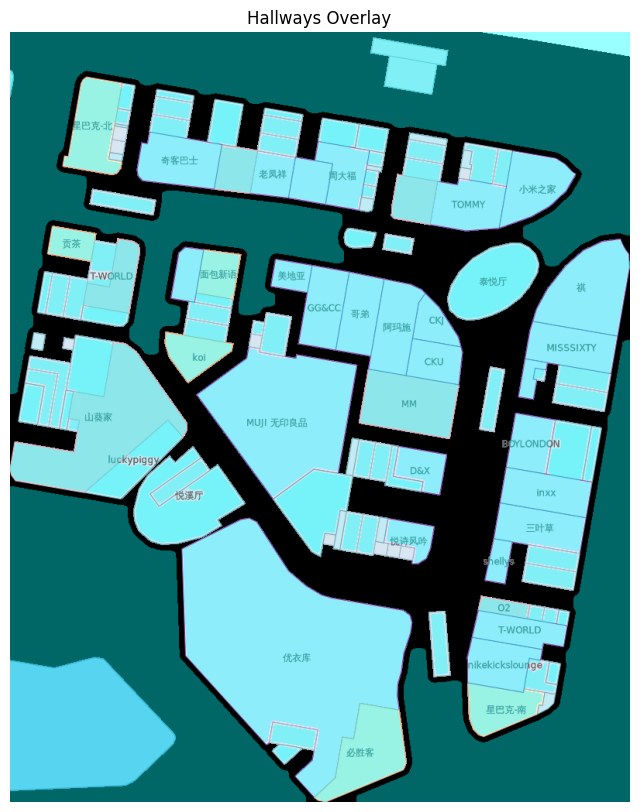

In [23]:
# 1) build the hallway mask
hall_mask, dbg = get_hallways_black_plus_teal(img_path, return_debug=True)

# 2) overlay so you can judge it
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(str(img_path)); img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
overlay = img.copy()
overlay[hall_mask > 0] = (0, 255, 255)           # cyan highlight
blended = cv2.addWeighted(img, 0.6, overlay, 0.4, 0)

plt.figure(figsize=(8,10)); plt.imshow(blended); plt.title("Hallways Overlay"); plt.axis('off'); plt.show()


# CAHTGPT OUTSIDE

In [20]:
import cv2
import numpy as np

def get_outside_mask(img_path, seed_xy=(5, 5), frame_thresh=60, dilate_iters=3):
    """
    Detects the area OUTSIDE the black frame/polygon.

    Returns:
        mask_outside (uint8 HxW): 255 where outside, 0 elsewhere
        dbg (dict): intermediate images for debugging
    """
    img = cv2.imread(img_path)  # BGR
    if img is None:
        raise ValueError(f"Could not read image: {img_path}")
    h, w = img.shape[:2]

    # 1) Find dark 'barrier' pixels (the black frame) in grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # black frame -> 1; everything else -> 0
    barrier = (gray < frame_thresh).astype(np.uint8) * 255

    # 2) Thicken the barrier to seal tiny gaps (tune dilate_iters if needed)
    k = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    barrier = cv2.dilate(barrier, k, iterations=dilate_iters)

    # 3) Create a "fillable" canvas: 255 where we can fill, 0 where barrier blocks
    fillable = cv2.bitwise_not(barrier)

    # 4) Flood-fill from the top-left corner (known outside)
    # OpenCV's floodFill needs a (H+2)x(W+2) mask
    ff = fillable.copy()
    ff_mask = np.zeros((h + 2, w + 2), dtype=np.uint8)
    sx, sy = seed_xy  # (x, y)
    # Fill the connected component starting at the seed with a distinct value (128)
    cv2.floodFill(ff, ff_mask, (sx, sy), 128, loDiff=0, upDiff=0, flags=4)

    # 5) The outside region is exactly what was filled to value 128
    mask_outside = (ff == 128).astype(np.uint8) * 255

    dbg = {
        "gray": gray,
        "barrier": barrier,
        "fillable": fillable,
        "flood_filled": ff
    }
    return mask_outside, dbg

def overlay_mask_yellow(img_path, mask, alpha=0.6, out_path=None):
    """
    Overlays a YELLOW tint (BGR=(0,255,255)) where mask>0 and returns the BGR image.
    """
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Could not read image: {img_path}")
    overlay = img.copy()
    overlay[mask > 0] = (0, 255, 255)  # yellow in BGR
    blended = cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0)
    if out_path:
        cv2.imwrite(out_path, blended)
    return blended


In [21]:
img_path = img_path
mask, dbg = get_outside_mask(
    img_path,
    seed_xy=(5, 5),      # top-left corner is outside
    frame_thresh=60,     # raise if the frame looks gray rather than black
    dilate_iters=3       # increase if there are tiny gaps in the frame
)

overlay = overlay_mask_yellow(img_path, mask, alpha=0.6, out_path="outside_overlay_yellow.png")
print("Saved → outside_overlay_yellow.png")


Saved → outside_overlay_yellow.png


In [22]:
import cv2
import numpy as np

def get_outside_mask_strict(img_path, seed_xy=None,
                            v_thresh=70, s_thresh=90, lab_L_thresh=85,
                            canny1=40, canny2=120, close_ks=5, dilate_iters=3):
    """
    Returns a binary mask where OUTSIDE the black frame = 255, inside = 0.
    The frame is treated as a strict barrier even if it has thin gaps.

    Args:
        img_path: path to the map image.
        seed_xy: optional (x,y) seed for flood-fill. If None, uses whole image border as seeds.
        v_thresh, s_thresh: HSV thresholds for 'dark + low saturation' (black-ish).
        lab_L_thresh: Lab L channel threshold for reinforcing darkness.
        canny1, canny2: Canny thresholds to capture thin black lines.
        close_ks: kernel size for morphological closing to seal gaps.
        dilate_iters: expands the barrier a bit after closing.

    Returns:
        outside_mask (uint8 HxW): 255 where outside, 0 elsewhere.
        dbg (dict): intermediate images if you want to inspect.
    """
    img = cv2.imread(img_path)  # BGR
    if img is None:
        raise ValueError(f"Could not read image: {img_path}")
    h, w = img.shape[:2]

    # --- 1) Detect dark/black linework (the frame) ---
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    H, S, V = cv2.split(hsv)
    # very dark & not saturated -> black-ish
    dark_hsv = (V < v_thresh) & (S < s_thresh)

    lab = cv2.cvtColor(img, cv2.COLOR_BGR2Lab)
    L, A, B = cv2.split(lab)
    dark_lab = (L < lab_L_thresh)

    dark_mask = (dark_hsv & dark_lab).astype(np.uint8) * 255

    # --- 2) Add edges to catch hairline strokes, then close tiny gaps ---
    edges = cv2.Canny(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), canny1, canny2)
    barrier = cv2.bitwise_or(dark_mask, edges)

    # Close small breaks and thicken slightly
    k = cv2.getStructuringElement(cv2.MORPH_RECT, (close_ks, close_ks))
    barrier = cv2.morphologyEx(barrier, cv2.MORPH_CLOSE, k)
    barrier = cv2.dilate(barrier, k, iterations=dilate_iters)

    # --- 3) Flood-fill OUTSIDE region ---
    # Fillable = anywhere that's not barrier
    fillable = cv2.bitwise_not(barrier)

    filled = np.zeros_like(fillable)
    ff_mask = np.zeros((h + 2, w + 2), dtype=np.uint8)

    def flood_from_seed(x, y):
        # copy so we can fill repeatedly without destroying 'fillable'
        tmp = fillable.copy()
        ff_mask[:] = 0
        cv2.floodFill(tmp, ff_mask, (x, y), 128, loDiff=0, upDiff=0, flags=4)
        return (tmp == 128)

    outside_bool = np.zeros((h, w), dtype=bool)
    if seed_xy is not None:
        sx, sy = seed_xy  # (x, y)
        outside_bool |= flood_from_seed(sx, sy)
    else:
        # seeds all along the border (robust when top-left might be cluttered)
        for x in range(0, w, max(1, w // 60)):
            outside_bool |= flood_from_seed(x, 0)
            outside_bool |= flood_from_seed(x, h - 1)
        for y in range(0, h, max(1, h // 60)):
            outside_bool |= flood_from_seed(0, y)
            outside_bool |= flood_from_seed(w - 1, y)

    outside_mask = (outside_bool.astype(np.uint8)) * 255

    dbg = {
        "dark_mask": dark_mask,
        "edges": edges,
        "barrier": barrier,
        "fillable": fillable,
        "outside_bool": outside_bool.astype(np.uint8) * 255
    }
    return outside_mask, dbg


def overlay_mask_yellow(img_path, mask, alpha=0.6, out_path=None):
    """
    Overlays a YELLOW tint (BGR=(0,255,255)) where mask>0 and returns the BGR image.
    """
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Could not read image: {img_path}")
    overlay = img.copy()
    overlay[mask > 0] = (0, 255, 255)  # yellow in BGR
    blended = cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0)
    if out_path:
        cv2.imwrite(out_path, blended)
    return blended


In [24]:
# Option A: rely on border seeding (recommended)
# outside_mask, dbg = get_outside_mask_strict(img_path)

# Option B: explicitly seed top-left (known outside)
outside_mask, dbg = get_outside_mask_strict(img_path, seed_xy=(5, 5))

overlay = overlay_mask_yellow(img_path, outside_mask, alpha=0.6, out_path="outside_only_yellow.png")
print("Saved → outside_only_yellow.png")

Saved → outside_only_yellow.png


In [37]:
import cv2
import numpy as np

def get_outside_mask_robust(img_path,
                            close_ratio=0.01,   # morphological kernel ~1% of min(H,W)
                            dilate_iters=2,     # beef up the barrier
                            seed_from_borders=True):
    """
    Find the area OUTSIDE the thick black frame by:
      1) detecting near-black pixels (auto thresholds),
      2) sealing small gaps (close + dilate),
      3) flood-filling from the image borders.

    Returns:
        outside_mask (uint8 HxW): 255 outside, 0 inside
        barrier (uint8 HxW): the final barrier used for filling
    """
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Could not read image: {img_path}")
    h, w = img.shape[:2]
    m = min(h, w)

    # ---- 1) Auto near-black detection (HSV + Lab + edges) ----
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # Otsu for dark pixels
    _, dark_otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    H, S, V = cv2.split(hsv)
    # dynamic thresholds from percentiles (robust to brightness)
    v_thr = np.percentile(V, 15)
    s_thr = np.percentile(S, 35)
    dark_hsv = ((V < v_thr) & (S < s_thr)).astype(np.uint8) * 255

    lab = cv2.cvtColor(img, cv2.COLOR_BGR2Lab)
    L, A, B = cv2.split(lab)
    L_thr = np.percentile(L, 30)
    dark_lab = (L < L_thr).astype(np.uint8) * 255

    edges = cv2.Canny(gray, 40, 140)

    # Combine all cues
    barrier = cv2.bitwise_or(dark_otsu, dark_hsv)
    barrier = cv2.bitwise_or(barrier, dark_lab)
    barrier = cv2.bitwise_or(barrier, edges)

    # ---- 2) Seal gaps so the outer stroke is a continuous barrier ----
    ksize = max(3, int(round(m * close_ratio)) | 1)  # odd size
    k = cv2.getStructuringElement(cv2.MORPH_RECT, (ksize, ksize))
    barrier = cv2.morphologyEx(barrier, cv2.MORPH_CLOSE, k)
    if dilate_iters > 0:
        barrier = cv2.dilate(barrier, k, iterations=dilate_iters)

    # ---- 3) Flood-fill from the borders -> outside only ----
    fillable = cv2.bitwise_not(barrier)
    filled = np.zeros_like(fillable)
    ff_mask = np.zeros((h + 2, w + 2), dtype=np.uint8)

    def ff(x, y):
        tmp = fillable.copy()
        ff_mask[:] = 0
        cv2.floodFill(tmp, ff_mask, (x, y), 128, loDiff=0, upDiff=0, flags=4)
        return (tmp == 128)

    outside = np.zeros((h, w), dtype=bool)
    if seed_from_borders:
        step_x = max(1, w // 80)
        step_y = max(1, h // 80)
        for x in range(0, w, step_x):
            outside |= ff(x, 0)
            outside |= ff(x, h - 1)
        for y in range(0, h, step_y):
            outside |= ff(0, y)
            outside |= ff(w - 1, y)
    else:
        outside |= ff(5, 5)  # top-left seed

    outside_mask = (outside.astype(np.uint8)) * 255
    return outside_mask, barrier


def overlay_mask_yellow(img_path, mask, alpha=0.6, out_path=None):
    img = cv2.imread(img_path)
    overlay = img.copy()
    overlay[mask > 0] = (0, 255, 255)  # yellow (BGR)
    blended = cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0)
    if out_path:
        cv2.imwrite(out_path, blended)
    return blended


In [38]:
outside_mask, barrier = get_outside_mask_robust(img_path, close_ratio=0.012, dilate_iters=2)
overlay = overlay_mask_yellow(img_path, outside_mask, alpha=0.6, out_path="outside_only_yellow.png")
print("Saved → outside_only_yellow.png")



Saved → outside_only_yellow.png


In [44]:
import cv2
import numpy as np

def get_outside_mask_transparent(img_path,
                                 alpha_clear_thr: int = 10,
                                 close_ks: int = 7,
                                 dilate_iters: int = 2):
    """
    Returns:
        outside_mask (uint8 HxW): 255 where OUTSIDE the black frame, 0 inside
        dbg (dict)
    Logic:
      • If RGBA: outside = transparent regions connected to the image border.
      • Else (no alpha): fall back to dark-line barrier + flood fill.
    """
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise ValueError(f"Could not read {img_path}")
    H, W = img.shape[:2]
    has_alpha = (img.ndim == 3 and img.shape[2] == 4)

    if has_alpha:
        # ----- Transparent-background case -----
        alpha = img[:, :, 3]
        # Transparent pixels (allowing anti-aliased edges)
        transparent = (alpha <= alpha_clear_thr).astype(np.uint8) * 255

        # Flood-fill ONLY the transparent area from all borders -> true outside
        ff = transparent.copy()
        ff_mask = np.zeros((H + 2, W + 2), dtype=np.uint8)

        step_x, step_y = max(1, W // 80), max(1, H // 80)
        for x in range(0, W, step_x):
            cv2.floodFill(ff, ff_mask, (x, 0),     128, flags=4)
            cv2.floodFill(ff, ff_mask, (x, H - 1), 128, flags=4)
        for y in range(0, H, step_y):
            cv2.floodFill(ff, ff_mask, (0, y),     128, flags=4)
            cv2.floodFill(ff, ff_mask, (W - 1, y), 128, flags=4)

        outside_mask = (ff == 128).astype(np.uint8) * 255
        dbg = {"transparent": transparent, "flood": ff}
        return outside_mask, dbg

    # ----- Fallback when there is NO alpha channel -----
    bgr = img if img.ndim == 3 else cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

    # Build a barrier from near-black pixels + edges
    _, dark = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    edges = cv2.Canny(gray, 40, 140)
    barrier = cv2.bitwise_or(dark, edges)

    # Seal small gaps in the outer stroke
    k = cv2.getStructuringElement(cv2.MORPH_RECT, (close_ks, close_ks))
    barrier = cv2.morphologyEx(barrier, cv2.MORPH_CLOSE, k)
    barrier = cv2.dilate(barrier, k, iterations=dilate_iters)

    # Flood-fill from borders on the inverse of the barrier
    fillable = cv2.bitwise_not(barrier)
    ff = fillable.copy()
    ff_mask = np.zeros((H + 2, W + 2), dtype=np.uint8)
    step_x, step_y = max(1, W // 80), max(1, H // 80)
    for x in range(0, W, step_x):
        cv2.floodFill(ff, ff_mask, (x, 0),     128, flags=4)
        cv2.floodFill(ff, ff_mask, (x, H - 1), 128, flags=4)
    for y in range(0, H, step_y):
        cv2.floodFill(ff, ff_mask, (0, y),     128, flags=4)
        cv2.floodFill(ff, ff_mask, (W - 1, y), 128, flags=4)

    outside_mask = (ff == 128).astype(np.uint8) * 255
    dbg = {"barrier": barrier, "fillable": fillable, "flood": ff}
    return outside_mask, dbg


def overlay_mask_yellow(img_path, mask, alpha=0.6, out_path=None):
    """Overlay yellow (BGR=(0,255,255)) where mask>0 and return the blended BGR image."""
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise ValueError(f"Could not read {img_path}")
    if img.ndim == 3 and img.shape[2] == 4:
        base = img[:, :, :3].copy()  # drop alpha for visualization
    else:
        base = img.copy()

    overlay = base.copy()
    overlay[mask > 0] = (0, 255, 255)
    blended = cv2.addWeighted(overlay, alpha, base, 1 - alpha, 0)
    if out_path:
        cv2.imwrite(out_path, blended)
    return blended


In [45]:
outside_mask, dbg = get_outside_mask_transparent(img_path, alpha_clear_thr=10)
overlay = overlay_mask_yellow(img_path, outside_mask, alpha=0.6, out_path="outside_overlay_yellow.png")
print("Saved → outside_overlay_yellow.png")

Saved → outside_overlay_yellow.png


In [46]:
import cv2
import numpy as np

def get_outside_mask_background_only(
    img_path,
    alpha_clear_thr: int = 10,   # transparent if alpha <= this
    s_bg_max: int = 35,          # background must be low-saturation
    v_bg_min: int = 50,          # avoid very dark (hallway black)
    v_bg_max: int = 245,         # avoid near-white (labels)
    smooth_ks: int = 5           # small close on final mask
):
    """
    OUTSIDE mask = 255 only where the pixels are (a) connected to the image border,
    and (b) look like BACKGROUND (transparent OR low-saturation HSV in a safe V range).
    This drops touching stores like MISSSIXTY.
    """
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise ValueError(f"Could not read {img_path}")
    H, W = img.shape[:2]
    has_alpha = (img.ndim == 3 and img.shape[2] == 4)

    # --- Candidate background pixels ---
    if has_alpha:
        alpha = img[:, :, 3]
        is_transparent = (alpha <= alpha_clear_thr)
        base_bgr = img[:, :, :3]
    else:
        is_transparent = np.zeros((H, W), dtype=bool)
        base_bgr = img if img.ndim == 3 else cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    hsv = cv2.cvtColor(base_bgr, cv2.COLOR_BGR2HSV)
    S = hsv[:, :, 1]
    V = hsv[:, :, 2]

    # Low-saturation, mid-value = background-like (avoid black corridors & bright labels)
    is_low_sat_bg = (S <= s_bg_max) & (V >= v_bg_min) & (V <= v_bg_max)

    candidate_bg = (is_transparent | is_low_sat_bg).astype(np.uint8) * 255

    # --- Flood-fill from borders but ONLY through candidate_bg ---
    ff = np.zeros_like(candidate_bg)
    work = candidate_bg.copy()
    ff_mask = np.zeros((H + 2, W + 2), dtype=np.uint8)

    def flood(x, y):
        if work[y, x] == 0:
            return
        cv2.floodFill(work, ff_mask, (x, y), 128, flags=4)

    step_x, step_y = max(1, W // 80), max(1, H // 80)
    for x in range(0, W, step_x):
        flood(x, 0); flood(x, H - 1)
    for y in range(0, H, step_y):
        flood(0, y); flood(W - 1, y)

    outside_mask = (work == 128).astype(np.uint8) * 255

    # Optional: tidy edges
    if smooth_ks > 0:
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (smooth_ks, smooth_ks))
        outside_mask = cv2.morphologyEx(outside_mask, cv2.MORPH_CLOSE, k)

    return outside_mask


In [47]:
def overlay_mask_yellow(img_path, mask, alpha=0.6, out_path=None):
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    base = img[:, :, :3].copy() if (img.ndim == 3 and img.shape[2] == 4) else img.copy()
    overlay = base.copy()
    overlay[mask > 0] = (0, 255, 255)  # yellow (BGR)
    blended = cv2.addWeighted(overlay, alpha, base, 1 - alpha, 0)
    if out_path:
        cv2.imwrite(out_path, blended)
    return blended


In [48]:
outside = get_outside_mask_background_only(
    img_path,
    alpha_clear_thr=10,   # raise to 15–20 if tiny transparent specks remain
    s_bg_max=35,         # lower to 25 if some pale stores still get included
    v_bg_min=60,         # raise if dark interior leaks in
    v_bg_max=240         # lower if bright labels get captured
)

overlay = overlay_mask_yellow(img_path, outside, out_path="outside_bg_only.png")
print("Saved → outside_bg_only.png")


Saved → outside_bg_only.png


In [51]:
import cv2
import numpy as np

def outside_mask_from_alpha_outer_contour(
    img_path: str,
    alpha_clear_thr: int = 10,  # alpha <= this => transparent
    close_ks: int = 5,          # seal 1px gaps in the opaque mask
):
    """
    OUTSIDE mask (255) = transparent background OR opaque pixels that are
    OUTSIDE the main mall outer contour (black frame polygon).
    This keeps all interior (stores + black corridors) unmasked,
    while including opaque islands outside (e.g., the blue pond).
    """
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise ValueError(f"Could not read {img_path}")
    if img.ndim < 3 or img.shape[2] < 4:
        raise ValueError("Image has no alpha channel; supply a PNG with transparency.")

    H, W = img.shape[:2]
    alpha = img[:, :, 3]

    # 1) Opaque mask (everything drawn: stores, corridors, frame, ponds, etc.)
    opaque = (alpha > alpha_clear_thr).astype(np.uint8) * 255

    # Seal hairline gaps along the outer frame so its contour is continuous
    if close_ks > 0:
        k = cv2.getStructuringElement(cv2.MORPH_RECT, (close_ks, close_ks))
        opaque = cv2.morphologyEx(opaque, cv2.MORPH_CLOSE, k)

    # 2) Find external contours of all opaque blobs
    contours, _ = cv2.findContours(opaque, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        # no opaque content => everything outside
        return np.ones((H, W), np.uint8) * 255

    # 3) Choose the MAIN mall contour = largest-area external contour
    #    (the mall is much larger than any outside island like the pond)
    mall_cnt = max(contours, key=cv2.contourArea)

    # 4) Fill the mall contour => inside region
    inside_mask = np.zeros((H, W), np.uint8)
    cv2.drawContours(inside_mask, [mall_cnt], -1, 255, thickness=cv2.FILLED)

    # 5) OUTSIDE = transparent OR (opaque but not inside the mall contour)
    outside_mask = np.zeros((H, W), np.uint8)
    outside_mask[(alpha <= alpha_clear_thr)] = 255
    outside_mask[(alpha > alpha_clear_thr) & (inside_mask == 0)] = 255

    return outside_mask


def overlay_mask_yellow(img_path, mask, alpha_blend=0.6, out_path=None):
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    base = img[:, :, :3].copy() if (img.ndim == 3 and img.shape[2] == 4) else img.copy()
    overlay = base.copy()
    overlay[mask > 0] = (0, 255, 255)   # yellow (BGR)
    blended = cv2.addWeighted(overlay, alpha_blend, base, 1 - alpha_blend, 0)
    if out_path:
        cv2.imwrite(out_path, blended)
    return blended


In [52]:

outside = outside_mask_from_alpha_outer_contour(
    img_path,
    alpha_clear_thr=10,  # if anti-aliased edges leak, raise to 15–20
    close_ks=5           # if the outer frame has gaps, try 7–9
)

_ = overlay_mask_yellow(img_path, outside, out_path="outside_final.png")
print("Saved → outside_final.png")


Saved → outside_final.png


In [57]:
import cv2
import numpy as np

def outside_mask_final(img_path,
                       v_thr=90, s_thr=80, L_thr=110,       # dark/black line thresholds
                       canny1=40, canny2=140,               # helps catch hairline strokes
                       close_ks=9, dilate_iters=2):         # seal gaps in the outer frame
    """
    Returns a binary mask (255=outside, 0=inside) where
    * the *outer black frame* is a hard barrier
    * interior black corridors are NOT outside
    * outside opaque polygons (e.g., blue pond) ARE outside
    """
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise ValueError(f"Could not read {img_path}")
    H, W = img.shape[:2]
    bgr = img[:, :, :3] if (img.ndim==3 and img.shape[2]==4) else img

    # 1) Detect candidate black strokes (outer frame + hallways)
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    hsv  = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    lab  = cv2.cvtColor(bgr, cv2.COLOR_BGR2Lab)
    V, S = hsv[:, :, 2], hsv[:, :, 1]
    L    = lab[:, :, 0]

    dark = ((V < v_thr) & (S < s_thr) & (L < L_thr)).astype(np.uint8) * 255
    edge = cv2.Canny(gray, canny1, canny2)

    cand = cv2.bitwise_or(dark, edge)

    # 2) Keep ONLY the outer frame contour:
    #    choose the largest *external* contour that encloses the image center and doesn't touch the image border
    k_close = cv2.getStructuringElement(cv2.MORPH_RECT, (close_ks, close_ks))
    cand_closed = cv2.morphologyEx(cand, cv2.MORPH_CLOSE, k_close)
    cand_closed = cv2.dilate(cand_closed, k_close, iterations=dilate_iters)

    cnts, _ = cv2.findContours(cand_closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        # fallback: consider all dark as barrier
        barrier = cand_closed
    else:
        cx0, cy0 = W/2.0, H/2.0
        def touches_border(x,y,w,h, m=2):
            return x<=m or y<=m or x+w>=W-m or y+h>=H-m
        # score contours: prefer large area, must contain center, must not touch border
        best = None
        best_score = -1
        for c in cnts:
            x,y,w,h = cv2.boundingRect(c)
            if touches_border(x,y,w,h): 
                continue
            if cv2.pointPolygonTest(c, (cx0, cy0), False) < 0:
                continue
            area = cv2.contourArea(c)
            if area > best_score:
                best = c
                best_score = area
        if best is None:
            # if nothing passes the strict test, fall back to largest contour
            best = max(cnts, key=cv2.contourArea)

        barrier = np.zeros((H, W), np.uint8)
        cv2.drawContours(barrier, [best], -1, 255, thickness=cv2.FILLED)

    # 3) Flood-fill from all borders through NOT-barrier -> outside only
    passable = cv2.bitwise_not(barrier)
    ff = passable.copy()
    ff_mask = np.zeros((H+2, W+2), dtype=np.uint8)
    step_x, step_y = max(1, W//80), max(1, H//80)
    for x in range(0, W, step_x):
        cv2.floodFill(ff, ff_mask, (x, 0),     128, flags=4)
        cv2.floodFill(ff, ff_mask, (x, H-1),   128, flags=4)
    for y in range(0, H, step_y):
        cv2.floodFill(ff, ff_mask, (0, y),     128, flags=4)
        cv2.floodFill(ff, ff_mask, (W-1, y),   128, flags=4)

    outside_mask = (ff == 128).astype(np.uint8) * 255
    return outside_mask

def overlay_mask_yellow(img_path, mask, alpha=0.6, out_path=None):
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    base = img[:, :, :3].copy() if (img.ndim==3 and img.shape[2]==4) else img.copy()
    overlay = base.copy()
    overlay[mask>0] = (0,255,255)
    out = cv2.addWeighted(overlay, alpha, base, 1-alpha, 0)
    if out_path: cv2.imwrite(out_path, out)
    return out


In [63]:

outside = outside_mask_final(
    img_path,
    v_thr=200, s_thr=80, L_thr=400,   # raise these if the frame looks lighter
    close_ks=18, dilate_iters=5       # increase if tiny gaps let the fill leak inside
)
_ = overlay_mask_yellow(img_path, outside, out_path="outside_only.png")
print("Saved → outside_only.png")


Saved → outside_only.png


In [64]:
import cv2
import numpy as np

def outside_mask_strict_outer_frame(
    img_path: str,
    v_thr: int = 95, s_thr: int = 90, L_thr: int = 115,  # how “black” a pixel must be
    canny1: int = 40, canny2: int = 140,                 # edge helper
    close_ks: int = 7, dilate_iters: int = 2             # seal gaps in the frame
) -> np.ndarray:
    """
    Return mask with 255 only OUTSIDE the mall's outer frame.
    Inside (stores + black corridors) stays 0 even when touching the frame.
    Also includes opaque outside polygons (ponds, etc).

    Works with PNGs with or without alpha.
    """
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise ValueError(f"Could not read {img_path}")
    H, W = img.shape[:2]
    bgr = img[:, :,:3] if (img.ndim==3 and img.shape[2]==4) else img

    # --- 1) Candidate black strokes (frame + corridors) ---
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    hsv  = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    lab  = cv2.cvtColor(bgr, cv2.COLOR_BGR2Lab)
    V, S = hsv[:, :, 2], hsv[:, :, 1]
    L    = lab[:, :, 0]

    blackish = ((V < v_thr) & (S < s_thr) & (L < L_thr)).astype(np.uint8) * 255
    edges    = cv2.Canny(gray, canny1, canny2)
    cand     = cv2.bitwise_or(blackish, edges)

    # Thicken & seal
    k = cv2.getStructuringElement(cv2.MORPH_RECT, (close_ks, close_ks))
    cand = cv2.morphologyEx(cand, cv2.MORPH_CLOSE, k)
    cand = cv2.dilate(cand, k, iterations=dilate_iters)

    # --- 2) Pick the ONE component that is the OUTER FRAME (not corridors) ---
    # Strategy: among external contours of 'cand', choose the one that:
    #   (a) encloses the image center, and
    #   (b) lies closest to the image border (outer stroke hugs the canvas border),
    #   (c) is large.
    cnts, _ = cv2.findContours(cand, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        # fallback: outside = flood through not-cand (may over/under mask but won’t crash)
        passable = cv2.bitwise_not(cand)
    else:
        cx0, cy0 = W / 2.0, H / 2.0
        def border_dist_score(c):
            x,y,w,h = cv2.boundingRect(c)
            # small margin to consider "near" border
            d = min(x, y, W - (x + w), H - (y + h))
            return d  # smaller is better (closer to border)

        scored = []
        for c in cnts:
            contains_center = cv2.pointPolygonTest(c, (cx0, cy0), False) >= 0
            if not contains_center:
                continue
            area = cv2.contourArea(c)
            d    = border_dist_score(c)
            # score: prefer closer to border and bigger area
            score = (-d, area)
            scored.append((score, c))

        if not scored:
            # if center test failed (e.g., frame not fully closed yet), fall back to largest contour
            frame_cnt = max(cnts, key=cv2.contourArea)
        else:
            frame_cnt = max(scored, key=lambda t: t[0])[1]

        # Build a *solid barrier mask* from that one contour only
        barrier = np.zeros((H, W), np.uint8)
        cv2.drawContours(barrier, [frame_cnt], -1, 255, thickness=cv2.FILLED)

        # NOTE: 'barrier' is the wall; we can pass everywhere else from the borders
        passable = cv2.bitwise_not(barrier)

    # --- 3) Flood from borders ONLY through 'passable' -> OUTSIDE ---
    ff = passable.copy()
    ff_mask = np.zeros((H + 2, W + 2), dtype=np.uint8)
    step_x, step_y = max(1, W // 80), max(1, H // 80)
    for x in range(0, W, step_x):
        cv2.floodFill(ff, ff_mask, (x, 0),     128, flags=4)
        cv2.floodFill(ff, ff_mask, (x, H - 1), 128, flags=4)
    for y in range(0, H, step_y):
        cv2.floodFill(ff, ff_mask, (0, y),     128, flags=4)
        cv2.floodFill(ff, ff_mask, (W - 1, y), 128, flags=4)

    outside_mask = (ff == 128).astype(np.uint8) * 255
    return outside_mask


def overlay_mask_yellow(img_path, mask, alpha=0.6, out_path=None):
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    base = img[:, :, :3].copy() if (img.ndim==3 and img.shape[2]==4) else img.copy()
    overlay = base.copy()
    overlay[mask > 0] = (0, 255, 255)
    out = cv2.addWeighted(overlay, alpha, base, 1 - alpha, 0)
    if out_path:
        cv2.imwrite(out_path, out)
    return out


In [65]:

outside = outside_mask_strict_outer_frame(
    img_path,
    v_thr=95, s_thr=90, L_thr=115,   # if the frame looks lighter: raise to e.g. 105/100/125
    close_ks=9, dilate_iters=2       # if flood leaks inside: bump to 11–13 or iters=3–4
)
_ = overlay_mask_yellow(img_path, outside, out_path="outside_strict.png")
print("Saved → outside_strict.png")


Saved → outside_strict.png


In [ ]:
import cv2
import numpy as np

def inside_mask_from_alpha_outer_contour(img_path, alpha_clear_thr=10, close_ks=5):
    """
    Returns a binary mask with 255 ONLY INSIDE the outer black frame (mall area).
    """
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise ValueError(f"Could not read {img_path}")
    H, W = img.shape[:2]
    if img.ndim < 3 or img.shape[2] < 4:
        raise ValueError("Image has no alpha channel; provide a PNG with transparency.")

    alpha = img[:, :, 3]
    opaque = (alpha > alpha_clear_thr).astype(np.uint8) * 255

    if close_ks > 0:
        k = cv2.getStructuringElement(cv2.MORPH_RECT, (close_ks, close_ks))
        opaque = cv2.morphologyEx(opaque, cv2.MORPH_CLOSE, k)

    contours, _ = cv2.findContours(opaque, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return np.zeros((H, W), np.uint8)

    # mall outer frame = largest external contour
    mall_cnt = max(contours, key=cv2.contourArea)

    inside_mask = np.zeros((H, W), np.uint8)
    cv2.drawContours(inside_mask, [mall_cnt], -1, 255, thickness=cv2.FILLED)
    return inside_mask

def crop_mask_to_inside(existing_mask, inside_mask):
    """
    Keep existing_mask only INSIDE the black frame.
    Both masks are uint8 (0/255), same H×W.
    """
    return cv2.bitwise_and(existing_mask, inside_mask)

# --- Usage A: get inside-only mask (yellow overlay if you want) ---
inside_only = inside_mask_from_alpha_outer_contour(img_path, alpha_clear_thr=10, close_ks=5)

# --- Usage B: if you already have 'outside_final' (or any mask) and want to KEEP only the part inside:
# inside_cut = crop_mask_to_inside(outside_final, inside_only)

# Optional overlay helper
def overlay_mask_yellow(img_path, mask, alpha=0.6, out_path=None):
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    base = img[:, :, :3] if (img.ndim==3 and img.shape[2]==4) else img
    overlay = base.copy()
    overlay[mask>0] = (0,255,255)
    out = cv2.addWeighted(overlay, alpha, base, 1-alpha, 0)
    if out_path: cv2.imwrite(out_path, out)
    return out




In [71]:
# Example visualization:
_ = overlay_mask_yellow(img_path, inside_only, out_path="inside_only_yellow.png")


In [72]:
import cv2
import numpy as np

# ---------- 1) INSIDE via alpha outer contour ----------
def inside_mask_from_alpha_outer_contour(img_path, alpha_clear_thr=10, close_ks=5):
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise ValueError(f"Could not read {img_path}")
    if img.ndim < 3 or img.shape[2] < 4:
        raise ValueError("PNG with alpha is required.")

    H, W = img.shape[:2]
    alpha = img[:, :, 3]
    opaque = (alpha > alpha_clear_thr).astype(np.uint8) * 255

    if close_ks > 0:
        k = cv2.getStructuringElement(cv2.MORPH_RECT, (close_ks, close_ks))
        opaque = cv2.morphologyEx(opaque, cv2.MORPH_CLOSE, k)

    cnts, _ = cv2.findContours(opaque, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return np.zeros((H, W), np.uint8)

    mall_cnt = max(cnts, key=cv2.contourArea)
    inside = np.zeros((H, W), np.uint8)
    cv2.drawContours(inside, [mall_cnt], -1, 255, thickness=cv2.FILLED)
    return inside

# ---------- 2) “Store” detection (your gates) ----------
def detect_store_mask(
    img_bgr,
    inside_mask,
    *,
    black_V_max=110, close_iters=3, dilate_black_px=1,
    white_S_max=80,  white_V_min=185,
    pastel_S_max=90, pastel_V_min=165,
    cyan_H=(80,100),  cyan_S_min=25,  cyan_V_min=110,
    blue_H=(90,140),  blue_S_min=25,  blue_V_min=110,
    purple_H=(120,175), purple_S_min=20, purple_V_min=105,
    min_area_px=80, shrink_px=1
):
    """Return mask (255) for store polygons inside the black frame."""
    H, W = img_bgr.shape[:2]
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # black outline/walls
    black = cv2.inRange(hsv, np.array([0,0,0], np.uint8),
                             np.array([180,255,black_V_max], np.uint8))
    black = cv2.morphologyEx(black, cv2.MORPH_CLOSE, np.ones((3,3), np.uint8), iterations=close_iters)
    if dilate_black_px > 0:
        k = 2*dilate_black_px+1
        black = cv2.dilate(black, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k,k)), 1)

    # broad light/white
    white = cv2.inRange(hsv, np.array([0,0,white_V_min], np.uint8),
                             np.array([180,white_S_max,255], np.uint8))

    # pastel gate: low S, high V (any hue)
    s = hsv[...,1]; v = hsv[...,2]
    pastel = np.zeros((H,W), np.uint8)
    pastel[(s <= pastel_S_max) & (v >= pastel_V_min)] = 255

    # explicit hues
    def hue_mask(h_lo, h_hi, s_min, v_min):
        return cv2.inRange(hsv,
                           np.array([h_lo, s_min, v_min], np.uint8),
                           np.array([h_hi, 255, 255], np.uint8))
    cyan   = hue_mask(*cyan_H,   cyan_S_min,   cyan_V_min)
    blue   = hue_mask(*blue_H,   blue_S_min,   blue_V_min)
    purple = hue_mask(*purple_H, purple_S_min, purple_V_min)

    # union, constrained to inside and not on the black walls
    stores = white | pastel | cyan | blue | purple
    stores = cv2.bitwise_and(stores, inside_mask)
    stores = cv2.bitwise_and(stores, cv2.bitwise_not(black))

    # clean + optional shrink so we don't touch wall pixels
    stores = cv2.morphologyEx(stores, cv2.MORPH_OPEN, np.ones((3,3), np.uint8), 1)

    if shrink_px > 0:
        k = 2*shrink_px+1
        stores = cv2.erode(stores, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k,k)), 1)

    # area filter
    cnts, _ = cv2.findContours(stores, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    keep = np.zeros_like(stores)
    for c in cnts:
        if cv2.contourArea(c) >= min_area_px:
            cv2.drawContours(keep, [c], -1, 255, thickness=cv2.FILLED)
    return keep

# ---------- 3) Final: inside minus stores = corridors/voids ----------
def get_corridor_mask(img_path,
                      alpha_clear_thr=10, close_ks=5,
                      **store_gate_kwargs):
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise ValueError(f"Could not read {img_path}")
    bgr = img[:, :, :3] if (img.ndim==3 and img.shape[2]==4) else img

    inside = inside_mask_from_alpha_outer_contour(img_path, alpha_clear_thr, close_ks)
    store_mask = detect_store_mask(bgr, inside, **store_gate_kwargs)
    corridor = cv2.bitwise_and(inside, cv2.bitwise_not(store_mask))
    return corridor, store_mask, inside

# ---------- Overlay helper ----------
def overlay_mask_yellow(img_path, mask, alpha=0.6, out_path=None):
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    base = img[:, :, :3] if (img.ndim==3 and img.shape[2]==4) else img
    overlay = base.copy()
    overlay[mask>0] = (0,255,255)  # yellow (BGR)
    out = cv2.addWeighted(overlay, alpha, base, 1-alpha, 0)
    if out_path: cv2.imwrite(out_path, out)
    return out


In [73]:
corridor_mask, store_mask, inside_mask = get_corridor_mask(
    img_path,
    alpha_clear_thr=10, close_ks=7,                    # frame sealing
    black_V_max=110, close_iters=3, dilate_black_px=1, # wall robustness
    white_S_max=80, white_V_min=185,
    pastel_S_max=90, pastel_V_min=165,
    cyan_H=(80,100),  cyan_S_min=25,  cyan_V_min=110,
    blue_H=(90,140),  blue_S_min=25,  blue_V_min=110,
    purple_H=(120,175), purple_S_min=20, purple_V_min=105,
    min_area_px=80, shrink_px=1
)

# Visualize only corridors (inside minus stores)
_ = overlay_mask_yellow(img_path, corridor_mask, out_path="corridors_only.png")
print("Saved → corridors_only.png")

Saved → corridors_only.png


In [76]:
import cv2
import numpy as np

# --- already provided earlier ---
# inside_mask_from_alpha_outer_contour(...)
# detect_store_mask(...)
# overlay_mask_yellow(...)
def detect_text_mask(img_bgr,
                     inside_mask=None,
                     min_area=20, max_area=4000,
                     min_aspect=0.15, max_aspect=8.0,
                     pad=1):
    """
    Returns 255 where text-like regions exist.
    Uses MSER with valid positional arguments.
    """
    H, W = img_bgr.shape[:2]
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # create MSER object with positional params
    mser = cv2.MSER_create(3, min_area, max_area)
    regions, _ = mser.detectRegions(gray)

    text_mask = np.zeros((H, W), np.uint8)
    for pts in regions:
        x, y, w, h = cv2.boundingRect(pts)
        if w == 0 or h == 0:
            continue
        ar = w / float(h)
        if not (min_aspect <= ar <= max_aspect):
            continue
        x0, y0 = max(0, x - pad), max(0, y - pad)
        x1, y1 = min(W, x + w + pad), min(H, y + h + pad)
        text_mask[y0:y1, x0:x1] = 255

    if inside_mask is not None:
        text_mask = cv2.bitwise_and(text_mask, inside_mask)

    text_mask = cv2.morphologyEx(text_mask, cv2.MORPH_CLOSE, np.ones((3,3), np.uint8), 1)
    return text_mask


# ----------  Final corridors with text removed ----------
def get_corridor_mask(img_path,
                      alpha_clear_thr=10, close_ks=5,
                      drop_text=True,
                      # store-gate knobs:
                      **store_gate_kwargs):
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise ValueError(f"Could not read {img_path}")
    bgr = img[:, :, :3] if (img.ndim==3 and img.shape[2]==4) else img

    inside = inside_mask_from_alpha_outer_contour(img_path, alpha_clear_thr, close_ks)
    store_mask = detect_store_mask(bgr, inside, **store_gate_kwargs)
    corridor = cv2.bitwise_and(inside, cv2.bitwise_not(store_mask))

    if drop_text:
        text_mask = detect_text_mask(
            bgr, inside_mask=inside,
            min_area=20, max_area=4000,   # widen if needed
            min_aspect=0.15, max_aspect=8.0, pad=1
        )
        corridor = cv2.bitwise_and(corridor, cv2.bitwise_not(text_mask))

    return corridor

# ---------- overlay helper (unchanged) ----------
def overlay_mask_yellow(img_path, mask, alpha=0.6, out_path=None):
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    base = img[:, :, :3] if (img.ndim==3 and img.shape[2]==4) else img
    overlay = base.copy()
    overlay[mask>0] = (0,255,255)
    out = cv2.addWeighted(overlay, alpha, base, 1-alpha, 0)
    if out_path: cv2.imwrite(out_path, out)
    return out


In [77]:
corridors_no_text = get_corridor_mask(
    img_path,
    alpha_clear_thr=10, close_ks=7,   # frame sealing
    # store gates (same as your v3):
    black_V_max=110, close_iters=3, dilate_black_px=1,
    white_S_max=80, white_V_min=185,
    pastel_S_max=90, pastel_V_min=165,
    cyan_H=(80,100),  cyan_S_min=25,  cyan_V_min=110,
    blue_H=(90,140),  blue_S_min=25,  blue_V_min=110,
    purple_H=(120,175), purple_S_min=20, purple_V_min=105,
    min_area_px=80, shrink_px=1,
    drop_text=True
)

_ = overlay_mask_yellow(img_path, corridors_no_text, out_path="corridors_no_text.png")
print("Saved → corridors_no_text.png")

Saved → corridors_no_text.png


In [78]:
import cv2
import numpy as np

def get_corridor_mask(
    img_path,
    alpha_clear_thr=10, close_ks=7,
    # --- store color gates (tighten/loosen these) ---
    white_S_max=75, white_V_min=195,      # ↑V_min, ↓S_max => fewer halos
    pastel_S_max=80, pastel_V_min=175,    # ↑V_min, ↓S_max to be stricter
    cyan_H=(80,100),  cyan_S_min=30,  cyan_V_min=120,
    blue_H=(90,140),  blue_S_min=30,  blue_V_min=120,
    purple_H=(120,175), purple_S_min=25, purple_V_min=115,
    # --- walls/outline robustness ---
    black_V_max=110, close_iters=3, dilate_black_px=1,
    # --- NEW: margins to kill halos ---
    store_clearance_px=3,   # expand stores before subtraction (try 3–6)
    wall_clearance_px=1,    # optional margin from black wall pixels
    # --- text clean up ---
    drop_text=True, text_min_area=15, text_max_area=2500,
    text_min_aspect=0.2, text_max_aspect=6.0, text_pad=1
):
    # --- read ---
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    if img is None: raise ValueError(f"Could not read {img_path}")
    bgr = img[:,:,:3] if img.ndim==3 and img.shape[2]==4 else img
    H, W = bgr.shape[:2]

    # --- inside via alpha outer contour ---
    alpha = img[:,:,3] if (img.ndim==3 and img.shape[2]==4) else np.full((H,W),255,np.uint8)
    opaque = (alpha > alpha_clear_thr).astype(np.uint8)*255
    if close_ks>0:
        k = cv2.getStructuringElement(cv2.MORPH_RECT,(close_ks,close_ks))
        opaque = cv2.morphologyEx(opaque, cv2.MORPH_CLOSE, k)
    cnts,_ = cv2.findContours(opaque, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    inside = np.zeros((H,W), np.uint8)
    if cnts: cv2.drawContours(inside,[max(cnts,key=cv2.contourArea)],-1,255,cv2.FILLED)

    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)

    # --- black walls ---
    black = cv2.inRange(hsv, np.array([0,0,0],np.uint8),
                             np.array([180,255,black_V_max],np.uint8))
    black = cv2.morphologyEx(black, cv2.MORPH_CLOSE, np.ones((3,3),np.uint8), iterations=close_iters)
    if dilate_black_px>0:
        k = 2*dilate_black_px+1
        black = cv2.dilate(black, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(k,k)), 1)

    # --- store detection (stricter) ---
    white = cv2.inRange(hsv, np.array([0,0,white_V_min],np.uint8),
                             np.array([180,white_S_max,255],np.uint8))
    s, v = hsv[:,:,1], hsv[:,:,2]
    pastel = np.zeros((H,W), np.uint8); pastel[(s<=pastel_S_max)&(v>=pastel_V_min)] = 255
    def hue_mask(hlo,hhi,smin,vmin):
        return cv2.inRange(hsv, np.array([hlo,smin,vmin],np.uint8),
                                np.array([hhi,255,255],np.uint8))
    cyan   = hue_mask(*cyan_H,   cyan_S_min,   cyan_V_min)
    blue   = hue_mask(*blue_H,   blue_S_min,   blue_V_min)
    purple = hue_mask(*purple_H, purple_S_min, purple_V_min)

    stores = white | pastel | cyan | blue | purple
    stores = cv2.bitwise_and(stores, inside)
    stores = cv2.bitwise_and(stores, cv2.bitwise_not(black))
    stores = cv2.morphologyEx(stores, cv2.MORPH_OPEN, np.ones((3,3),np.uint8), 1)

    # --- halo fix #1: clearance from stores ---
    if store_clearance_px>0:
        k = 2*store_clearance_px+1
        stores = cv2.dilate(stores, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(k,k)), 1)

    # --- base corridors (inside minus stores) ---
    corridor = cv2.bitwise_and(inside, cv2.bitwise_not(stores))

    # --- halo fix #2: optional clearance from walls ---
    if wall_clearance_px>0:
        k = 2*wall_clearance_px+1
        wall_band = cv2.dilate(black, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(k,k)), 1)
        corridor = cv2.bitwise_and(corridor, cv2.bitwise_not(wall_band))

    # --- remove text (MSER) ---
    if drop_text:
        gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
        mser = cv2.MSER_create(3, text_min_area, text_max_area)  # fixed positional args
        regions,_ = mser.detectRegions(gray)
        text = np.zeros((H,W), np.uint8)
        for pts in regions:
            x,y,w,h = cv2.boundingRect(pts)
            ar = w/float(h) if h else 999
            if not (text_min_aspect <= ar <= text_max_aspect): continue
            x0,y0 = max(0,x-text_pad), max(0,y-text_pad)
            x1,y1 = min(W,x+w+text_pad), min(H,y+h+text_pad)
            text[y0:y1,x0:x1] = 255
        text = cv2.bitwise_and(text, inside)
        text = cv2.morphologyEx(text, cv2.MORPH_CLOSE, np.ones((3,3),np.uint8), 1)
        corridor = cv2.bitwise_and(corridor, cv2.bitwise_not(text))

    return corridor


In [79]:
corridors = get_corridor_mask(
    img_path,
    # stricter store thresholds
    white_S_max=70, white_V_min=205,
    pastel_S_max=75, pastel_V_min=190,
    cyan_H=(80,100),  cyan_S_min=30,  cyan_V_min=125,
    blue_H=(90,140),  blue_S_min=30,  blue_V_min=125,
    purple_H=(120,175), purple_S_min=25, purple_V_min=120,
    # margins
    store_clearance_px=4,
    wall_clearance_px=2
)

In [80]:
_ = overlay_mask_yellow(img_path, corridors_no_text, out_path="corridors_no_text_last.png")
print("Saved → corridors_no_text_last.png")

Saved → corridors_no_text_last.png


In [81]:
import cv2
import numpy as np

def thin_black_text_mask(img_bgr, inside_mask=None,
                         v_thr=105, s_thr=110,  # what counts as "black"
                         min_stroke_px=4):      # remove strokes thinner than ~this width
    """
    Returns 255 where black strokes are *thin* (likely text).
    min_stroke_px is the approximate full stroke width in pixels.
    """
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    hsv  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    V, S = hsv[:, :, 2], hsv[:, :, 1]

    # Black pixels (very dark & not saturated)
    black = ((V < v_thr) & (S < s_thr)).astype(np.uint8) * 255

    # Optional: only care about thin black *inside* the mall
    if inside_mask is not None:
        black = cv2.bitwise_and(black, inside_mask)

    # Distance transform on black foreground
    # (distance ~ half the local stroke width)
    dist = cv2.distanceTransform(black, cv2.DIST_L2, 3)

    # Pixels with half-width < min_stroke_px/2 are thin
    thin = (dist < (min_stroke_px / 2.0)).astype(np.uint8) * 255

    # Clean specks
    thin = cv2.morphologyEx(thin, cv2.MORPH_OPEN, np.ones((3,3), np.uint8), 1)
    return thin

def corridors_without_text(img_path,
                           get_inside_fn,      # your inside-mask function
                           detect_stores_fn,   # your store mask function (gates)
                           **kwargs_for_stores):
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    bgr = img[:, :, :3] if (img.ndim==3 and img.shape[2]==4) else img

    # 1) inside
    inside = get_inside_fn(img_path)

    # 2) stores
    stores = detect_stores_fn(bgr, inside, **kwargs_for_stores)

    # 3) corridors (inside minus stores)
    corridor = cv2.bitwise_and(inside, cv2.bitwise_not(stores))

    # 4) remove thin black strokes (text)
    thin_text = thin_black_text_mask(bgr, inside_mask=inside,
                                     v_thr=105, s_thr=110,   # tune if needed
                                     min_stroke_px=4)        # ~4–6 works well
    corridor = cv2.bitwise_and(corridor, cv2.bitwise_not(thin_text))
    return corridor


In [90]:
# Use the inside-mask function you liked ("outside_final" logic → inside):
inside_fn = lambda p: inside_mask_from_alpha_outer_contour(p, alpha_clear_thr=10, close_ks=7)

# Use your store detector (the v3 gates you posted):
def stores_fn(img_bgr, inside_mask, **k):
    return detect_store_mask(
        img_bgr, inside_mask,
        black_V_max=110, close_iters=3, dilate_black_px=1,
        white_S_max=80, white_V_min=185,
        pastel_S_max=90, pastel_V_min=165,
        cyan_H=(80,100),  cyan_S_min=25,  cyan_V_min=110,
        blue_H=(90,140),  blue_S_min=25,  blue_V_min=110,
        purple_H=(120,175), purple_S_min=20, purple_V_min=105,
        min_area_px=80, shrink_px=1
    )

corridors = corridors_without_text(img_path, inside_fn, stores_fn)

_ = overlay_mask_yellow(img_path, corridors, out_path="corridors_thickness_no_text.png")
print("Saved → corridors_thickness_no_text.png")


Saved → corridors_thickness_no_text.png


# Gemini

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# The magic command that tells Jupyter/IPython to render Matplotlib figures inline
%matplotlib inline

In [15]:
# --- 1. Mask Creation Function (Hallways Only) ---

def create_floor_mask(image_path: str) -> np.ndarray:
    """
    Detects the free space (hallways) inside the main black outline,
    excluding the colorful internal polygons (stores).
    Returns a [0, 255] NumPy array mask.
    """
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Could not open or find the image at: {image_path}")

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Isolate the entire drawing area (building + stores)
    _, thresh_full = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY_INV)

    # Find the main outer contour (Building Perimeter)
    contours_ext, _ = cv2.findContours(thresh_full, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours_ext:
        return np.zeros(gray.shape, dtype=np.uint8)
    
    main_contour = max(contours_ext, key=cv2.contourArea)

    # Create a mask for the *entire* area inside the main contour
    mask = np.zeros(gray.shape, dtype=np.uint8)
    cv2.drawContours(mask, [main_contour], 0, 255, -1) 

    # Find contours for the colorful polygons (Stores)
    _, store_thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY)
    contours_stores, _ = cv2.findContours(store_thresh, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

    # Erase the store polygons from the mask
    for contour in contours_stores:
        if cv2.contourArea(contour) > 50: 
            M = cv2.moments(contour)
            if M["m00"] != 0:
                cX = int(M["m10"] / M["m00"])
                cY = int(M["m01"] / M["m00"])
                
                if cv2.pointPolygonTest(main_contour, (cX, cY), False) >= 0:
                    cv2.drawContours(mask, [contour], 0, 0, -1) 

    return mask

# --- 2. Overlay Plotting Function (Visualization for Notebooks) ---

def plot_mask_overlay_fixed(image_path: str, mask: np.ndarray, color=(0, 255, 0), alpha=0.5) -> np.ndarray:
    """
    Applies the mask as a transparent color overlay STRICTLY on the masked areas.
    """
    original_img = cv2.imread(image_path)
    if original_img is None:
        raise FileNotFoundError(f"Could not open or find the image at: {image_path}")
        
    # **CRITICAL:** Convert BGR (OpenCV) to RGB (Matplotlib)
    original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    
    output_img = original_img.copy() 
    
    # Convert BGR overlay color to RGB for Matplotlib (e.g., Green (0, 255, 0) is the same)
    color_rgb = (color[2], color[1], color[0]) 

    # Prepare mask for blending
    mask_3_channel = cv2.merge([mask, mask, mask]).astype(np.float32) / 255.0

    # Create the color layer
    colored_layer = np.zeros_like(original_img, dtype=np.uint8)
    colored_layer[:, :] = color_rgb 

    # Correct Blending Formula
    output_img = (
        (colored_layer * (alpha * mask_3_channel)) + 
        (output_img * (1 - alpha * mask_3_channel))
    ).astype(np.uint8)

    return output_img



Mask created successfully (NumPy array).


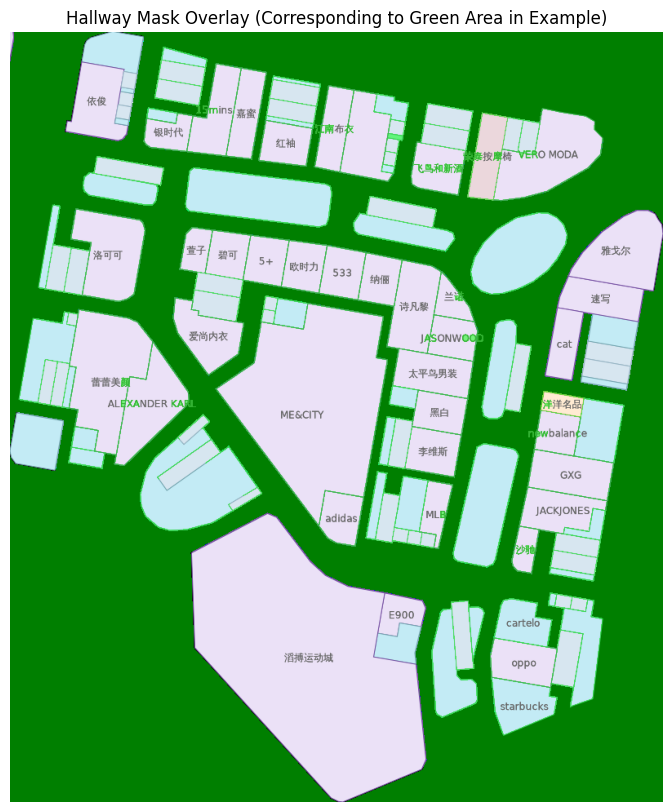

In [16]:
# --- 3. Execution Block ---

image_file = img_path # Ensure this is the correct filename/path
overlay_color = (0, 255, 0) # Green in BGR (will display as green by Matplotlib)

try:
    # 1. Create the mask
    hallway_mask = create_floor_mask(image_file)
    print("Mask created successfully (NumPy array).")
    
    # 2. Plot the overlay image
    overlay_img = plot_mask_overlay_fixed(image_file, hallway_mask, color=overlay_color, alpha=0.5)
    
    # 3. Display the result using Matplotlib
    plt.figure(figsize=(10, 10))
    plt.imshow(overlay_img)
    plt.title("Hallway Mask Overlay (Corresponding to Green Area in Example)")
    plt.axis('off')
    # **CRITICAL:** Use plt.show() to ensure display in some notebook environments
    plt.show() 

except FileNotFoundError as e:
    print(f"ERROR: {e}. Please ensure the image file '{image_file}' is in the correct directory.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

# SHIFTZURIM

In [11]:
import cv2
import numpy as np

# ---------- helpers ----------
def inside_mask_from_alpha_outer_contour(img_path, alpha_clear_thr=10, close_ks=7):
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    if img is None: raise ValueError(f"Could not read {img_path}")
    if img.ndim < 3 or img.shape[2] < 4:
        raise ValueError("PNG with alpha is required for this inside-mask method.")
    H, W = img.shape[:2]
    alpha = img[:, :, 3]
    opaque = (alpha > alpha_clear_thr).astype(np.uint8) * 255
    if close_ks > 0:
        k = cv2.getStructuringElement(cv2.MORPH_RECT, (close_ks, close_ks))
        opaque = cv2.morphologyEx(opaque, cv2.MORPH_CLOSE, k)
    cnts, _ = cv2.findContours(opaque, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    inside = np.zeros((H, W), np.uint8)
    if cnts:
        mall_cnt = max(cnts, key=cv2.contourArea)
        cv2.drawContours(inside, [mall_cnt], -1, 255, thickness=cv2.FILLED)
    return inside

def detect_store_mask(
    img_bgr, inside_mask,
    *,
    black_V_max=110, close_iters=3, dilate_black_px=1,
    white_S_max=80, white_V_min=185,
    pastel_S_max=90, pastel_V_min=165,
    cyan_H=(80,100),  cyan_S_min=25,  cyan_V_min=110,
    blue_H=(90,140),  blue_S_min=25,  blue_V_min=110,
    purple_H=(120,175), purple_S_min=20, purple_V_min=105,
    min_area_px=80, shrink_px=1
):
    H, W = img_bgr.shape[:2]
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # black walls
    black = cv2.inRange(hsv, np.array([0,0,0], np.uint8),
                             np.array([180,255,black_V_max], np.uint8))
    black = cv2.morphologyEx(black, cv2.MORPH_CLOSE, np.ones((3,3), np.uint8), iterations=close_iters)
    if dilate_black_px > 0:
        k = 2*dilate_black_px+1
        black = cv2.dilate(black, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k,k)), 1)

    # broad light/white & pastel
    white  = cv2.inRange(hsv, np.array([0,0,white_V_min], np.uint8),
                              np.array([180,white_S_max,255], np.uint8))
    s, v = hsv[...,1], hsv[...,2]
    pastel = np.zeros((H,W), np.uint8); pastel[(s<=pastel_S_max) & (v>=pastel_V_min)] = 255

    # explicit hues
    def hue_mask(hlo, hhi, smin, vmin):
        return cv2.inRange(hsv, np.array([hlo,smin,vmin],np.uint8),
                                np.array([hhi,255,255],np.uint8))
    cyan   = hue_mask(*cyan_H,   cyan_S_min,   cyan_V_min)
    blue   = hue_mask(*blue_H,   blue_S_min,   blue_V_min)
    purple = hue_mask(*purple_H, purple_S_min, purple_V_min)

    stores = white | pastel | cyan | blue | purple
    stores = cv2.bitwise_and(stores, inside_mask)
    stores = cv2.bitwise_and(stores, cv2.bitwise_not(black))
    stores = cv2.morphologyEx(stores, cv2.MORPH_OPEN, np.ones((3,3), np.uint8), 1)

    # optional small shrink so we don't touch walls
    if shrink_px > 0:
        k = 2*shrink_px+1
        stores = cv2.erode(stores, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(k,k)), 1)

    # drop tiny specks
    cnts, _ = cv2.findContours(stores, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    clean = np.zeros_like(stores)
    for c in cnts:
        if cv2.contourArea(c) >= min_area_px:
            cv2.drawContours(clean, [c], -1, 255, thickness=cv2.FILLED)
    return clean

def thin_black_text_mask(img_bgr, inside_mask=None, v_thr=105, s_thr=110, min_stroke_px=4):
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    V, S = hsv[:, :, 2], hsv[:, :, 1]
    black = ((V < v_thr) & (S < s_thr)).astype(np.uint8) * 255
    if inside_mask is not None:
        black = cv2.bitwise_and(black, inside_mask)
    # optional: erode a hair to make labels thinner
    black = cv2.erode(black, np.ones((3,3), np.uint8), 1)
    dist = cv2.distanceTransform(black, cv2.DIST_L2, 3)
    thin = (dist < (min_stroke_px/2.0)).astype(np.uint8) * 255
    thin = cv2.morphologyEx(thin, cv2.MORPH_OPEN, np.ones((3,3), np.uint8), 1)
    return thin

def stores_union_polygon(store_mask, simplify_eps=2.0):
    """
    Returns:
      polygon (Nx2 int32) for the union (single external contour) of all stores,
      polygon_simplified (optional simplified version),
    If stores are split into disjoint islands, this returns the *outer* union boundary
    (drawn by combining and refinding contours).
    """
    H, W = store_mask.shape[:2]
    # union boundary
    cnts, _ = cv2.findContours(store_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts: 
        return None, None
    # draw them into one mask then get a single external contour of the union
    canvas = np.zeros((H,W), np.uint8)
    cv2.drawContours(canvas, cnts, -1, 255, thickness=cv2.FILLED)
    u_cnts, _ = cv2.findContours(canvas, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    # choose largest union ring
    uc = max(u_cnts, key=cv2.contourArea)
    uc = uc.reshape(-1,2)

    # simplify
    eps = simplify_eps
    approx = cv2.approxPolyDP(uc.astype(np.float32), eps, True).reshape(-1,2).astype(np.int32)
    return uc.astype(np.int32), approx

# ---------- MAIN ----------
def corridors_without_text_main(
    img_path,
    *,
    alpha_clear_thr=10, close_ks=7,
    # store-gate params (your v3 defaults)
    black_V_max=110, close_iters=3, dilate_black_px=1,
    white_S_max=80, white_V_min=185,
    pastel_S_max=90, pastel_V_min=165,
    cyan_H=(80,100),  cyan_S_min=25,  cyan_V_min=110,
    blue_H=(90,140),  blue_S_min=25,  blue_V_min=110,
    purple_H=(120,175), purple_S_min=20, purple_V_min=105,
    min_area_px=80, shrink_px=1,
    # text suppression by stroke width
    text_v_thr=105, text_s_thr=110, text_min_stroke_px=4,
    # store union polygon simplification
    simplify_eps=2.0,
    # extra margins (optional)
    store_clearance_px=0, wall_clearance_px=0
):
    """
    Returns:
      corridors_mask (uint8 HxW, 0/255),
      store_polygon (Nx2 int32)  -- union boundary,
      store_polygon_simplified (Nx2 int32) -- optional lighter boundary
    """
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    if img is None: raise ValueError(f"Could not read {img_path}")
    bgr = img[:, :, :3] if (img.ndim==3 and img.shape[2]==4) else img
    H, W = bgr.shape[:2]

    # inside via alpha outer contour
    inside = inside_mask_from_alpha_outer_contour(img_path, alpha_clear_thr, close_ks)

    # store mask
    store_mask = detect_store_mask(
        bgr, inside,
        black_V_max=black_V_max, close_iters=close_iters, dilate_black_px=dilate_black_px,
        white_S_max=white_S_max, white_V_min=white_V_min,
        pastel_S_max=pastel_S_max, pastel_V_min=pastel_V_min,
        cyan_H=cyan_H, cyan_S_min=cyan_S_min, cyan_V_min=cyan_V_min,
        blue_H=blue_H, blue_S_min=blue_S_min, blue_V_min=blue_V_min,
        purple_H=purple_H, purple_S_min=purple_S_min, purple_V_min=purple_V_min,
        min_area_px=min_area_px, shrink_px=shrink_px
    )

    # optional clearance margins
    if store_clearance_px > 0:
        k = 2*store_clearance_px+1
        store_mask = cv2.dilate(store_mask, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(k,k)), 1)
    if wall_clearance_px > 0:
        hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
        black = cv2.inRange(hsv, np.array([0,0,0],np.uint8),
                                 np.array([180,255,black_V_max],np.uint8))
        band = cv2.dilate(black, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(2*wall_clearance_px+1, 2*wall_clearance_px+1)), 1)
        inside = cv2.bitwise_and(inside, cv2.bitwise_not(band))

    # corridors = inside minus stores
    corridors = cv2.bitwise_and(inside, cv2.bitwise_not(store_mask))

    # remove thin black text by stroke width
    thin_text = thin_black_text_mask(bgr, inside_mask=inside, v_thr=text_v_thr, s_thr=text_s_thr, min_stroke_px=text_min_stroke_px)
    corridors = cv2.bitwise_and(corridors, cv2.bitwise_not(thin_text))

    # union polygon of stores
    store_poly, store_poly_simpl = stores_union_polygon(store_mask, simplify_eps=simplify_eps)

    return corridors, store_poly, store_poly_simpl


In [12]:

corridors_mask, store_poly, store_poly_simple = corridors_without_text_main(
    img_path,
    alpha_clear_thr=10, close_ks=7,
    # keep your store gates as-is; tune only if needed
    text_min_stroke_px=5,   # raise if any letters remain
    simplify_eps=3.0        # raise to simplify polygon more
)

print("corridors_mask shape:", corridors_mask.shape)
print("store_poly points:", None if store_poly is None else len(store_poly))


corridors_mask shape: (944, 800)
store_poly points: 368


In [13]:
import cv2
import matplotlib.pyplot as plt

def plot_store_polygon(img_path, store_poly, corridors_mask=None, color=(255, 0, 0)):
    """
    Draws store polygon and optionally overlays corridors on the original image.
    """
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    base = img[:, :, :3] if (img.ndim==3 and img.shape[2]==4) else img.copy()

    overlay = base.copy()

    # Optional corridors overlay
    if corridors_mask is not None:
        overlay[corridors_mask > 0] = (0, 255, 255)  # yellow corridors

    # Draw polygon (blue/red)
    if store_poly is not None and len(store_poly) > 2:
        cv2.polylines(overlay, [store_poly], isClosed=True, color=color, thickness=3)

    # Convert BGR to RGB for plotting
    overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10,10))
    plt.imshow(overlay_rgb)
    plt.axis("off")
    plt.title("Store Polygon over Floorplan")
    plt.show()


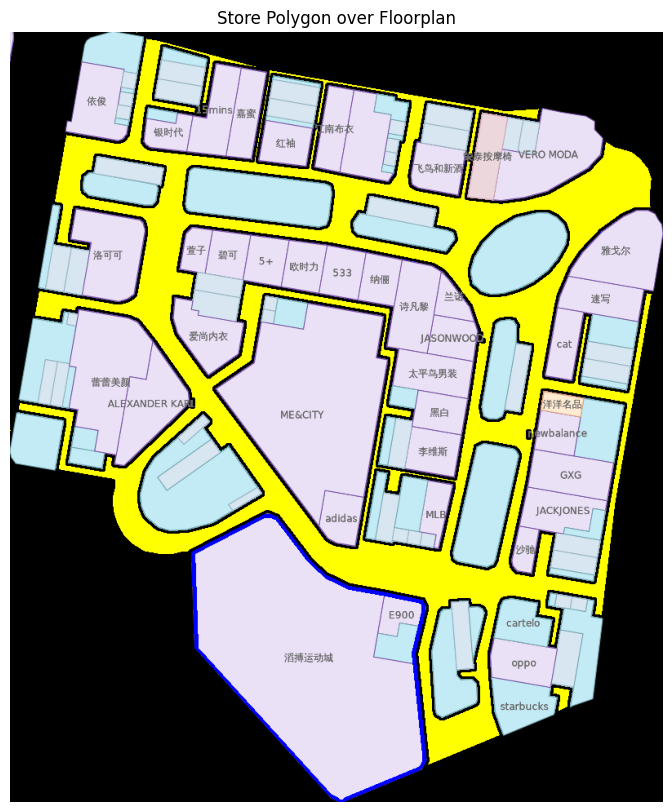

In [14]:
plot_store_polygon(img_path, store_poly, corridors_mask)
